Dataset link : https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+succes

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.1 MB/s eta 0:00:00


#Introduction

The primary objective of this machine learning project is to accurately predict student academic outcomes—specifically identifying whether a student will Graduate, Dropout, or remain Enrolled. Student retention and academic success are critical metrics for higher education institutions. By leveraging predictive modeling, universities can proactively identify at-risk students and implement targeted intervention strategies to reduce dropout rates and improve overall institutional performance.

To achieve this, the project utilizes a comprehensive dataset originally sourced from the Instituto Politécnico de Portalegre (IPP), a public higher education institution in Portugal. Collected as part of a case study aimed at reducing academic failure and dropout rates, this dataset has been integrated into the UCI Machine Learning Repository. It encompasses a rich variety of data points, including real-world demographic factors, socio-economic backgrounds, admissions criteria, and detailed semester-by-semester academic performance metrics.

To find the most reliable predictive system, we will train and evaluate multiple machine learning algorithms, like Random Forest and Gradient Boosting.

The project is structured into a complete machine learning workflow through the following sequential phases: Dataset Description, Exploration, Data Preprocessing, Feature Selection, Model Training and Hyperparameter Tuning, and finally, Model Comparison.

# Importing librairies

In [ ]:
import itertools
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Importing dataset

In [ ]:
df = pd.read_csv('data.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


#Dataset presentation

The dataset used in this project is the Predict Students’ Dropout and Academic Success dataset from the UCI Machine Learning Repository.

The dataset was designed to predict student academic outcomes in higher education, including dropout, continued enrollment, and graduation.

The dataset contains variables such as :

Demographic	: Gender, Age at enrollment, Nationality...

Academic :	Admission grade, Curricular units approved...

Socioeconomic	: Scholarship holder, Debtor status...

Macroeconomic :	Inflation rate, GDP...

In [ ]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
print(f"{df.shape[0]:,} students — {df.shape[1]-1} features")

4,424 students — 36 features


### Variable types

In [ ]:
type_map = {
    "Marital status"                        : "Categorical",
    "Application mode"                      : "Categorical",
    "Application order"                     : "Ordinal",
    "Course"                                : "Categorical",
    "Daytime/evening attendance"            : "Binary",
    "Previous qualification"                : "Categorical",
    "Previous qualification (grade)"        : "Continuous",
    "Nacionality"                           : "Categorical",
    "Mother's qualification"                : "Categorical",
    "Father's qualification"                : "Categorical",
    "Mother's occupation"                   : "Categorical",
    "Father's occupation"                   : "Categorical",
    "Admission grade"                       : "Continuous",
    "Displaced"                             : "Binary",
    "Educational special needs"             : "Binary",
    "Debtor"                                : "Binary",
    "Tuition fees up to date"               : "Binary",
    "Gender"                                : "Binary",
    "Scholarship holder"                    : "Binary",
    "Age at enrollment"                     : "Continuous",
    "International"                         : "Binary",
    "Curricular units 1st sem (credited)"   : "Discrete",
    "Curricular units 1st sem (enrolled)"   : "Discrete",
    "Curricular units 1st sem (evaluations)": "Discrete",
    "Curricular units 1st sem (approved)"   : "Discrete",
    "Curricular units 1st sem (grade)"      : "Continuous",
    "Curricular units 1st sem (without evaluations)": "Discrete",
    "Curricular units 2nd sem (credited)"   : "Discrete",
    "Curricular units 2nd sem (enrolled)"   : "Discrete",
    "Curricular units 2nd sem (evaluations)": "Discrete",
    "Curricular units 2nd sem (approved)"   : "Discrete",
    "Curricular units 2nd sem (grade)"      : "Continuous",
    "Curricular units 2nd sem (without evaluations)": "Discrete",
    "Unemployment rate"                     : "Continuous",
    "Inflation rate"                        : "Continuous",
    "GDP"                                   : "Continuous",
}

pd.DataFrame(type_map.items(), columns=["Variable", "Type"])

,Variable,Type
0,Marital status,Categorical
1,Application mode,Categorical
2,Application order,Ordinal
3,Course,Categorical
4,Daytime/evening attendance,Binary
5,Previous qualification,Categorical
6,Previous qualification (grade),Continuous
7,Nacionality,Categorical
8,Mother's qualification,Categorical
9,Father's qualification,Categorical


In [ ]:
df_types = pd.DataFrame(type_map.items(), columns=["Variable", "Type"])
df_types["Type"].value_counts()

,count
Type,
Discrete,10
Categorical,9
Binary,8
Continuous,8
Ordinal,1


# Exploratory Data Analysis

In [ ]:
print(f'Missing values : {df.isnull().sum().sum()}')

Missing values : 0


We are satisfied to see that there is no missing values in the dataset

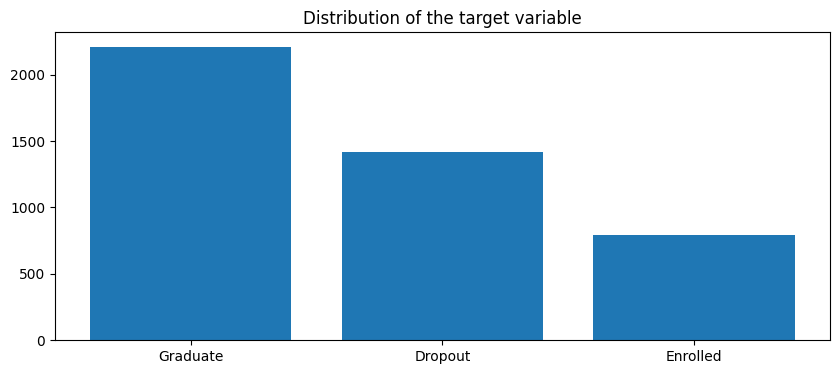

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(df['Target'].value_counts().index, df['Target'].value_counts())
plt.title('Distribution of the target variable')
plt.show()

With this graph, we can clearly see a class imbalance with more graduates compared to dropouts and enrolled students. Building predictive models requires addressing this imbalance to prevent a bias toward the majority 'graduate' class."

Techniques to Address
- Resampling: Oversampling the minority classes or undersampling the majority class.
- Adjusting Class Weights: Modifying the weights assigned to each class in the model to give more importance to the minority classes.

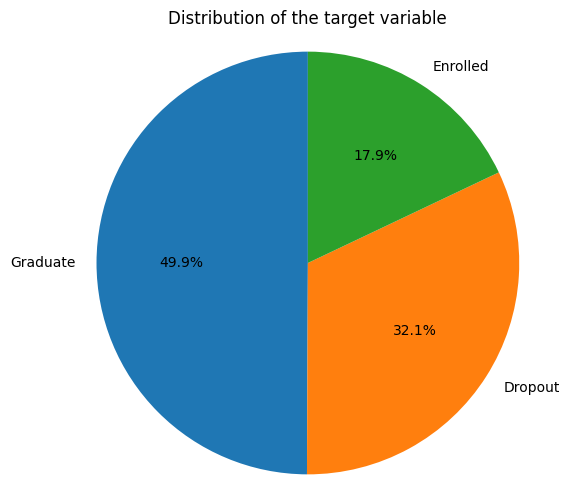

In [ ]:
counts = df['Target'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of the target variable')
plt.axis('equal')
plt.show()

In [ ]:
df['Target'] = df['Target'].map({'Graduate': 0, 'Dropout': 1, 'Enrolled': 2})

Since the target is categorical, we have to transform it into numerical data

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


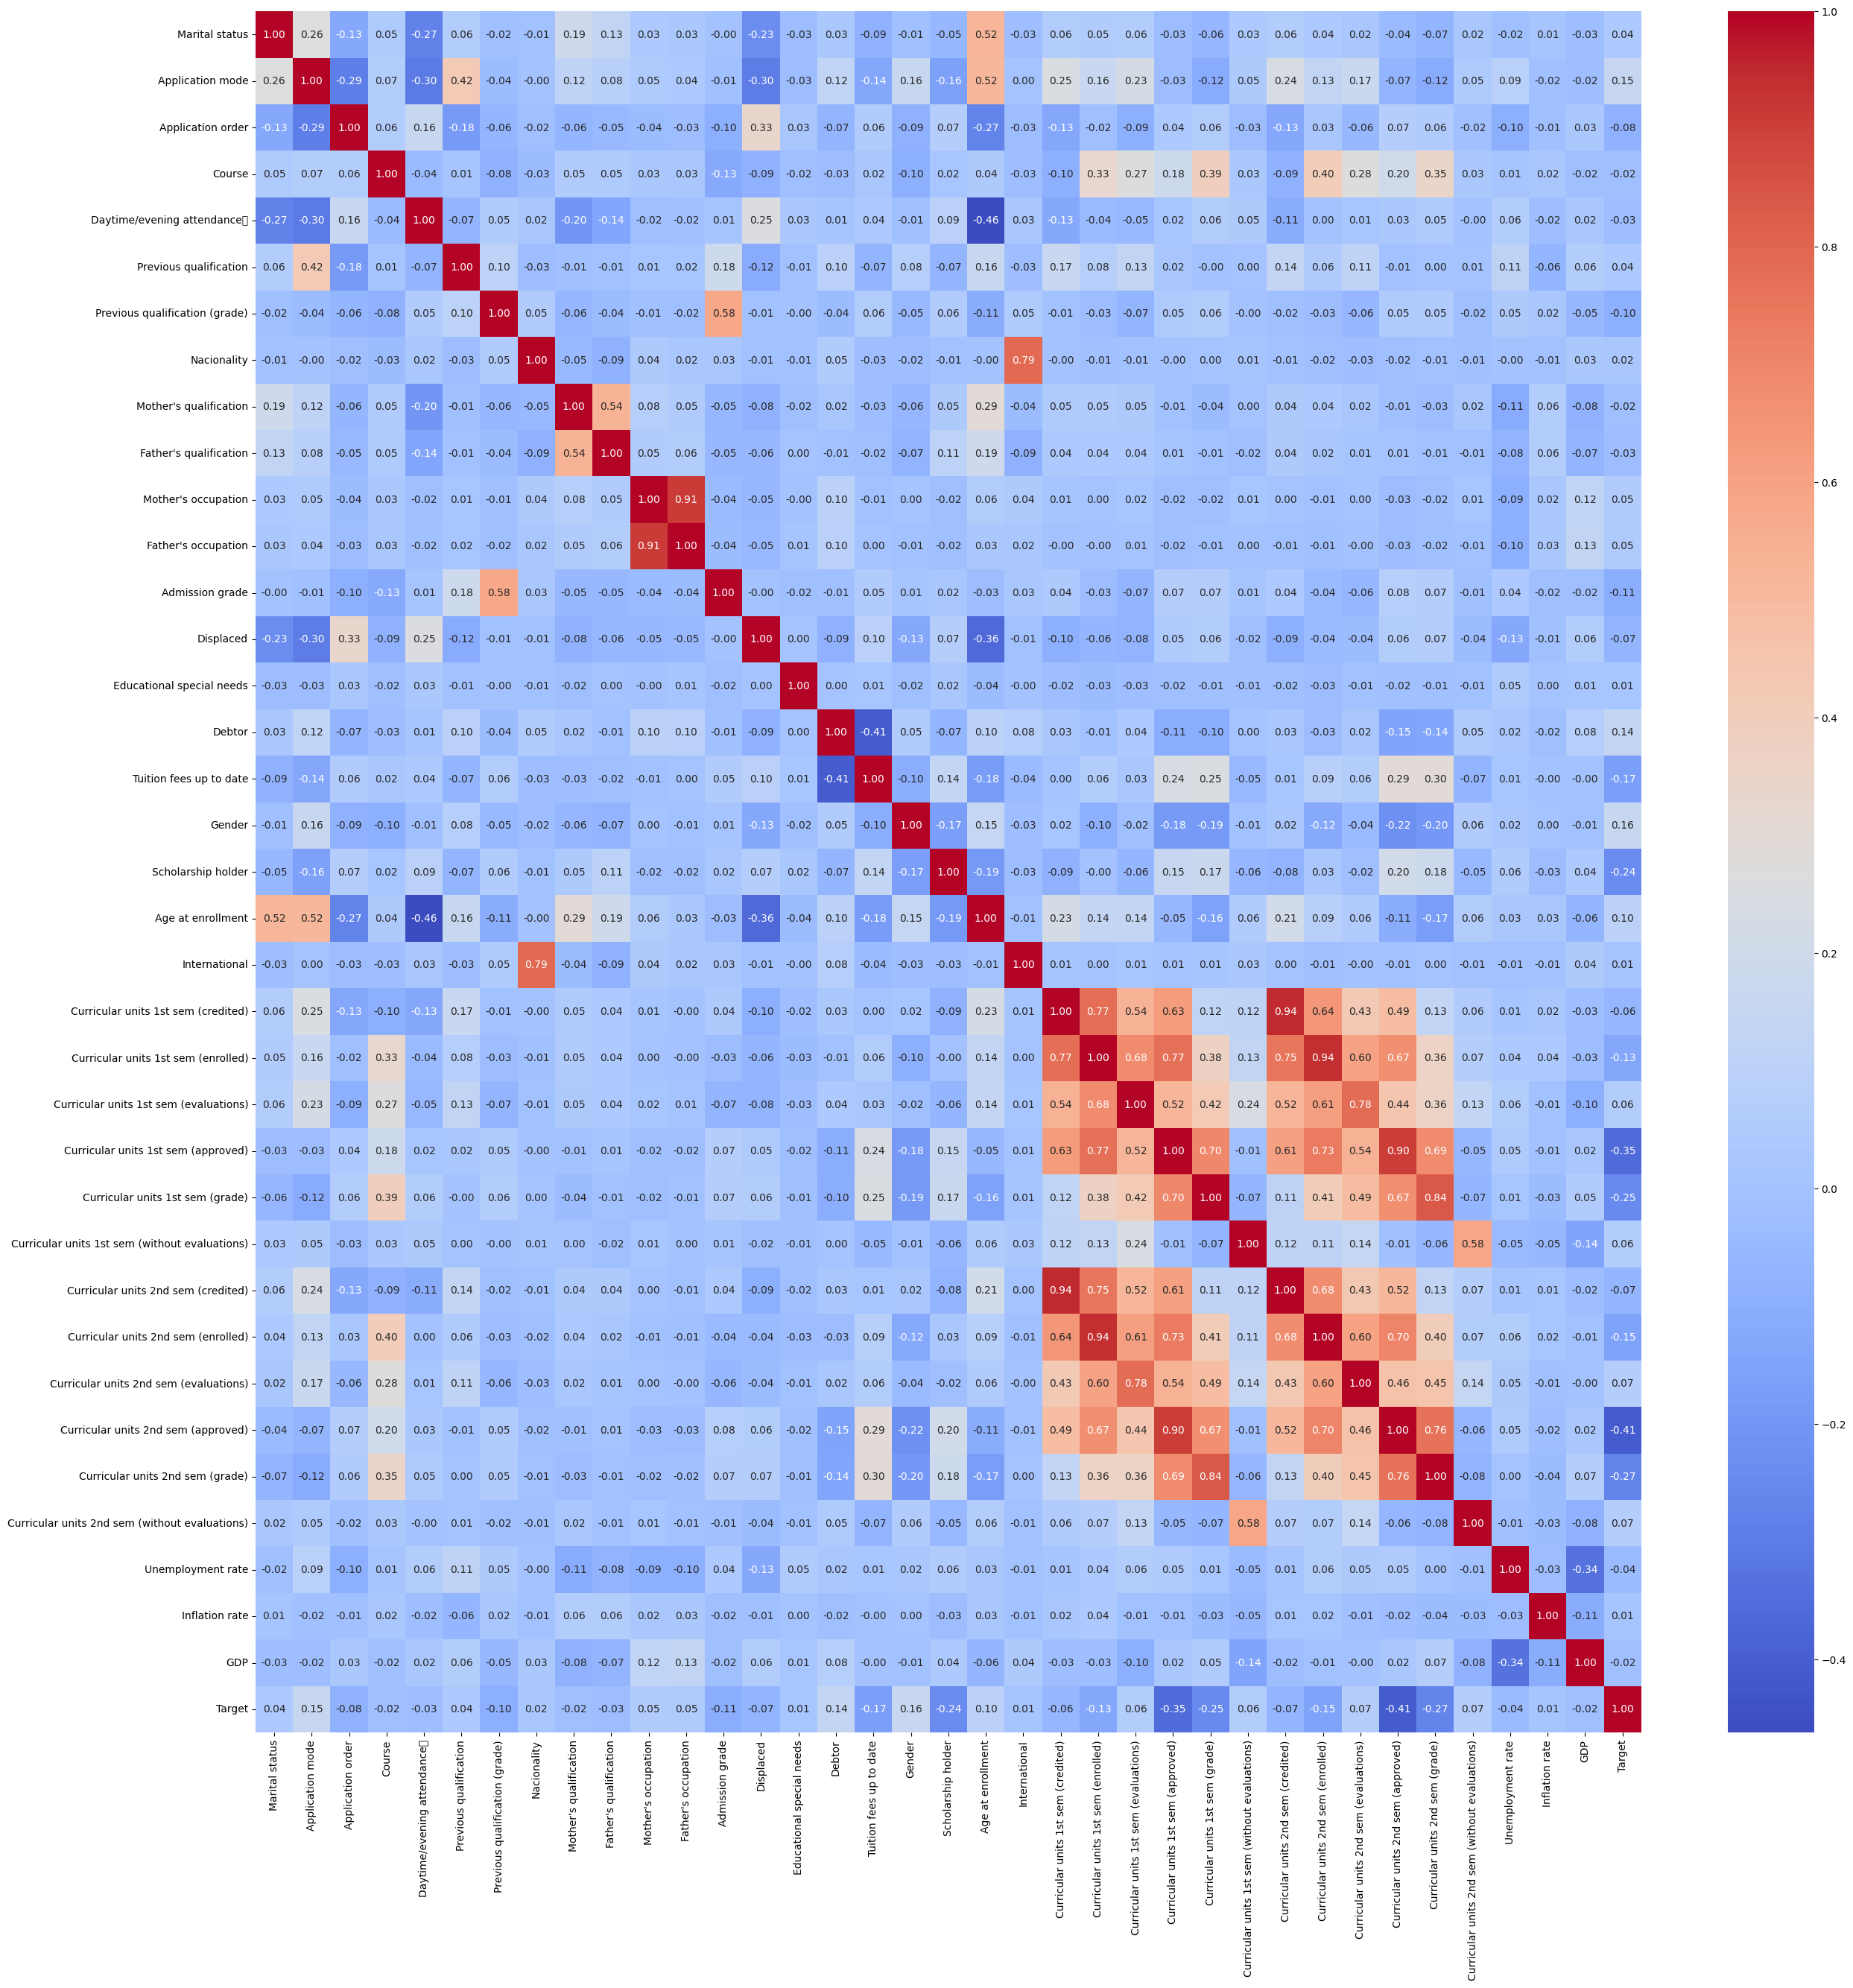

In [ ]:
plt.figure(figsize=(30,30))
ax = sns.heatmap(df.corr(), fmt='.2f', annot=True, cmap='coolwarm')

The correlation matrix reveals that academic success is primarily driven by immediate performance metrics, specifically the number of curricular units approved and the grades achieved during the first two semesters.

There are strong "clusters" of high correlation : There is a strong correlation between enrolled, approved, and evaluations within the same semester.

Macroeconomic factors like GDP, Inflation rate, and Unemployment rate show very weak correlations with individual student success in this specific dataset.

/tmp/ipykernel_1850/3635926363.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(labels)
/tmp/ipykernel_1850/3635926363.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels)


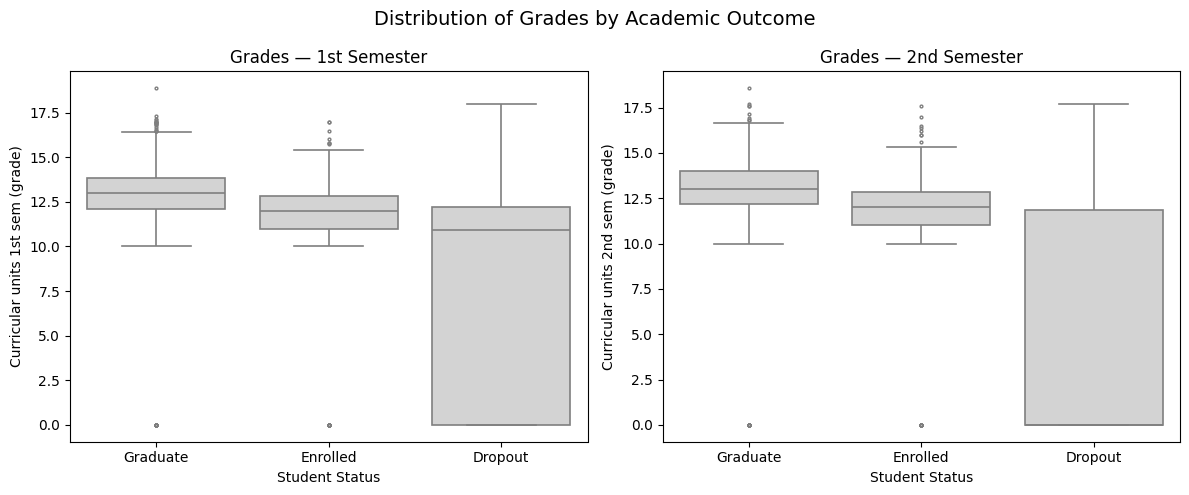

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
numeric_order = [0, 2, 1]
labels = ['Graduate', 'Enrolled', 'Dropout']

sns.boxplot(data=df, x='Target', y='Curricular units 1st sem (grade)',
            order=numeric_order, color='lightgray', ax=axes[0], linewidth=1.2, fliersize=2)
axes[0].set_title('Grades — 1st Semester')
axes[0].set_xlabel('Student Status')
axes[0].set_xticklabels(labels)

sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)',
            order=numeric_order, color='lightgray', ax=axes[1], linewidth=1.2, fliersize=2)
axes[1].set_title('Grades — 2nd Semester')
axes[1].set_xlabel('Student Status')
axes[1].set_xticklabels(labels)

plt.suptitle('Distribution of Grades by Academic Outcome', fontsize=14)
plt.tight_layout()
plt.show()

As expected, 'Graduate' status is associated with a higher grades. However, the presence of zero values for these features within the 'Graduate' class indicates potential anomalies. These were identified as outliers and subsequently removed.

/tmp/ipykernel_1850/4066928599.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels)


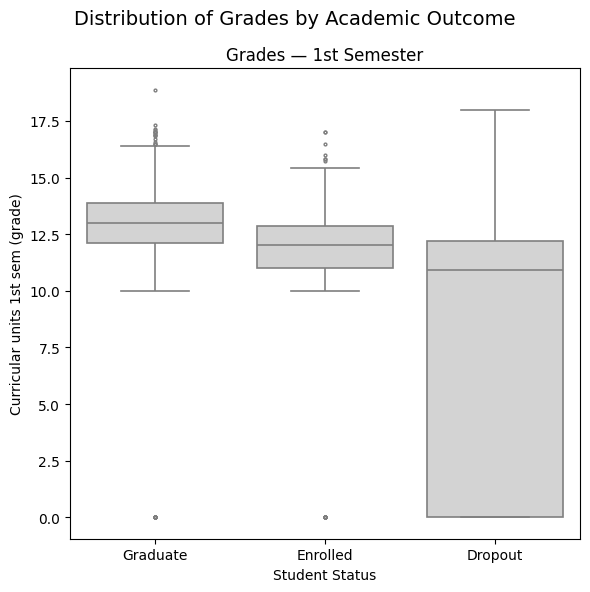

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

numeric_order = [0, 2, 1]
labels = ['Graduate', 'Enrolled', 'Dropout']

sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 1st sem (grade)',
    order=numeric_order,
    color='lightgray',
    ax=axes,
    linewidth=1.2,
    fliersize=2
)

axes.set_title('Grades — 1st Semester')
axes.set_xlabel('Student Status')
axes.set_xticklabels(labels)

plt.suptitle('Distribution of Grades by Academic Outcome', fontsize=14)
plt.tight_layout()
plt.show()

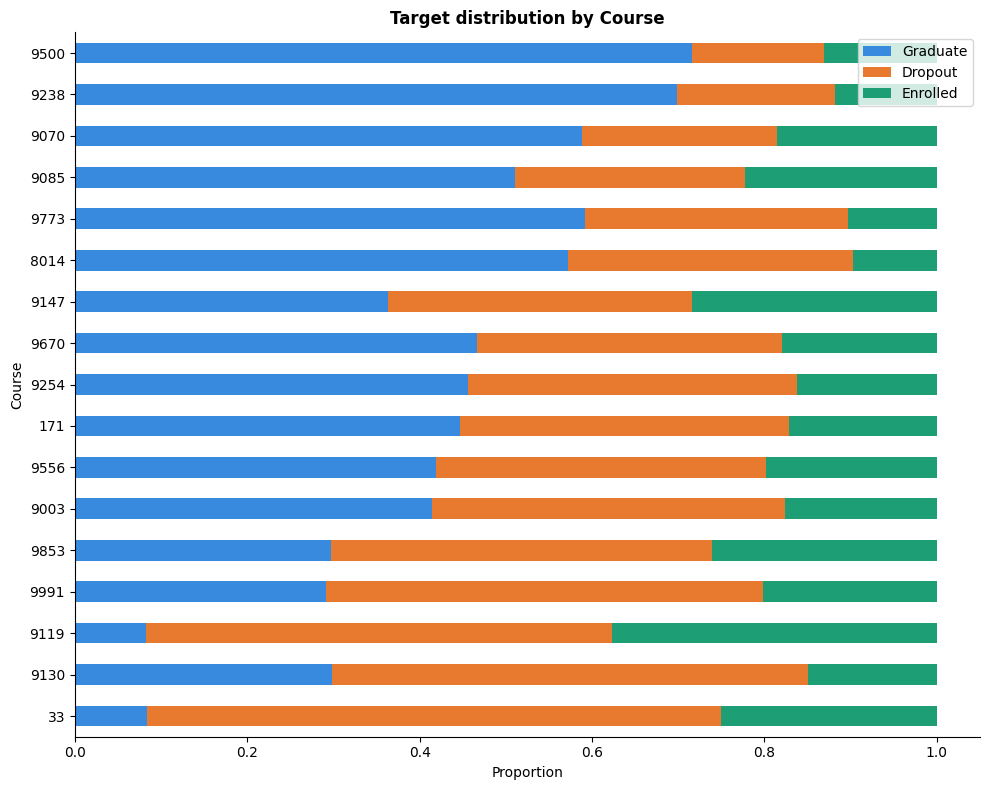

        Graduate  Dropout  Enrolled    n
Course                                  
33         0.083    0.667     0.250   12
9130       0.298    0.553     0.149  141
9119       0.082    0.541     0.376  170
9991       0.291    0.507     0.201  268
9853       0.297    0.443     0.260  192
9003       0.414    0.410     0.176  210
9556       0.419    0.384     0.198   86
171        0.447    0.381     0.172  215
9254       0.456    0.381     0.163  252
9670       0.466    0.354     0.179  268
9147       0.363    0.353     0.284  380
8014       0.572    0.330     0.098  215
9773       0.592    0.305     0.103  331
9085       0.510    0.267     0.223  337
9070       0.588    0.226     0.186  226
9238       0.699    0.183     0.118  355
9500       0.715    0.154     0.131  766


In [ ]:
course_target = df.groupby("Course")["Target"].value_counts(normalize=True).unstack().fillna(0)
course_target.columns = ["Graduate", "Dropout", "Enrolled"]
course_target["n"] = df.groupby("Course")["Target"].count()
course_target = course_target.sort_values("Dropout", ascending=False)

course_target.drop(columns="n").plot.barh(stacked=True, figsize=(10, 8),
    color=["#378ADD", "#E87A30", "#1D9E75"])
plt.title("Target distribution by Course", fontweight="bold")
plt.xlabel("Proportion")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(course_target.round(3).to_string())

33 - Biofuel Production Technologies has the highest dropout rate but only 12 student has this course. On an other hand, 9500 - Nursing has the highest graduate rate and is also the course with the most student 766.

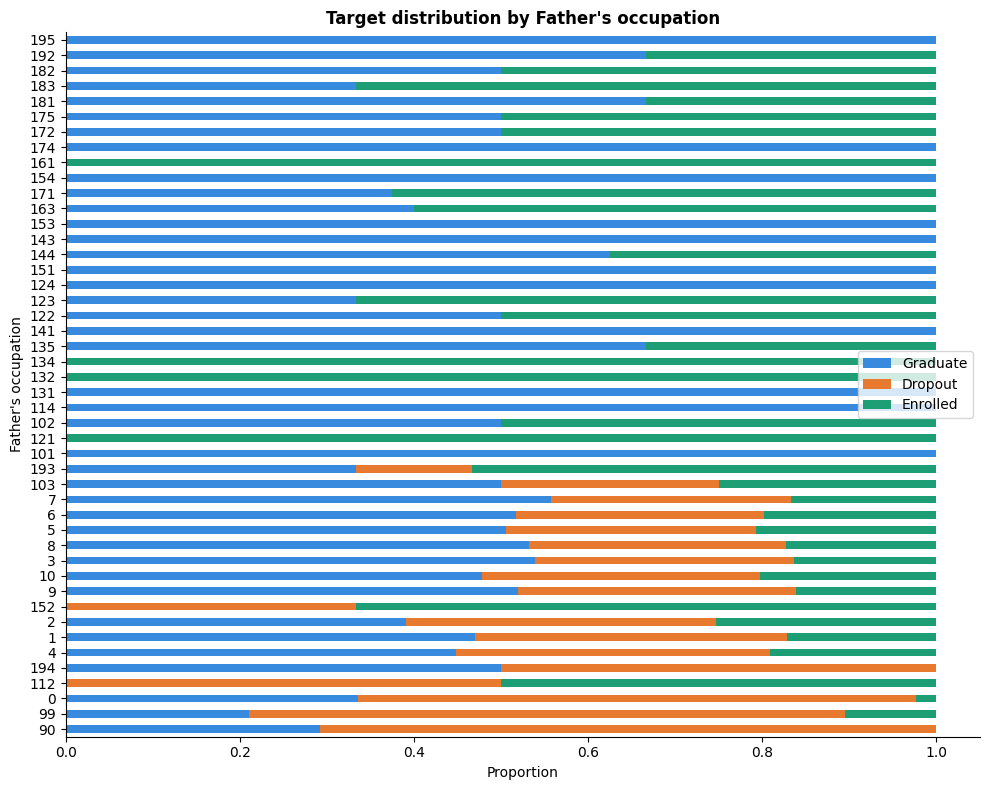

                     Graduate  Dropout  Enrolled     n
Father's occupation                                   
90                      0.292    0.708     0.000    65
99                      0.211    0.684     0.105    19
0                       0.336    0.641     0.023   128
112                     0.000    0.500     0.500     2
194                     0.500    0.500     0.000     2
4                       0.448    0.360     0.192   386
1                       0.470    0.358     0.172   134
2                       0.391    0.355     0.254   197
152                     0.000    0.333     0.667     3
9                       0.519    0.320     0.161  1010
10                      0.477    0.320     0.203   266
3                       0.539    0.297     0.164   384
8                       0.531    0.296     0.173   318
5                       0.506    0.287     0.207   516
6                       0.517    0.285     0.198   242
7                       0.557    0.276     0.167   666
103       

In [ ]:
course_target = df.groupby("Father's occupation")["Target"].value_counts(normalize=True).unstack().fillna(0)
course_target.columns = ["Graduate", "Dropout", "Enrolled"]
course_target["n"] = df.groupby("Father's occupation")["Target"].count()
course_target = course_target.sort_values("Dropout", ascending=False)

course_target.drop(columns="n").plot.barh(stacked=True, figsize=(10, 8),
    color=["#378ADD", "#E87A30", "#1D9E75"])
plt.title("Target distribution by Father's occupation", fontweight="bold")
plt.xlabel("Proportion")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(course_target.round(3).to_string())

0 - Student 90 - Other Situation 99 - (blank) have the highest dropout rate. In an other hand, 7 - Skilled Workers in Industry and 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry, Construction and Craftsmen have the highest graduate rate. There a lot of Father's occupation that appears only few time so we can't make good statistical interpretation about their result.

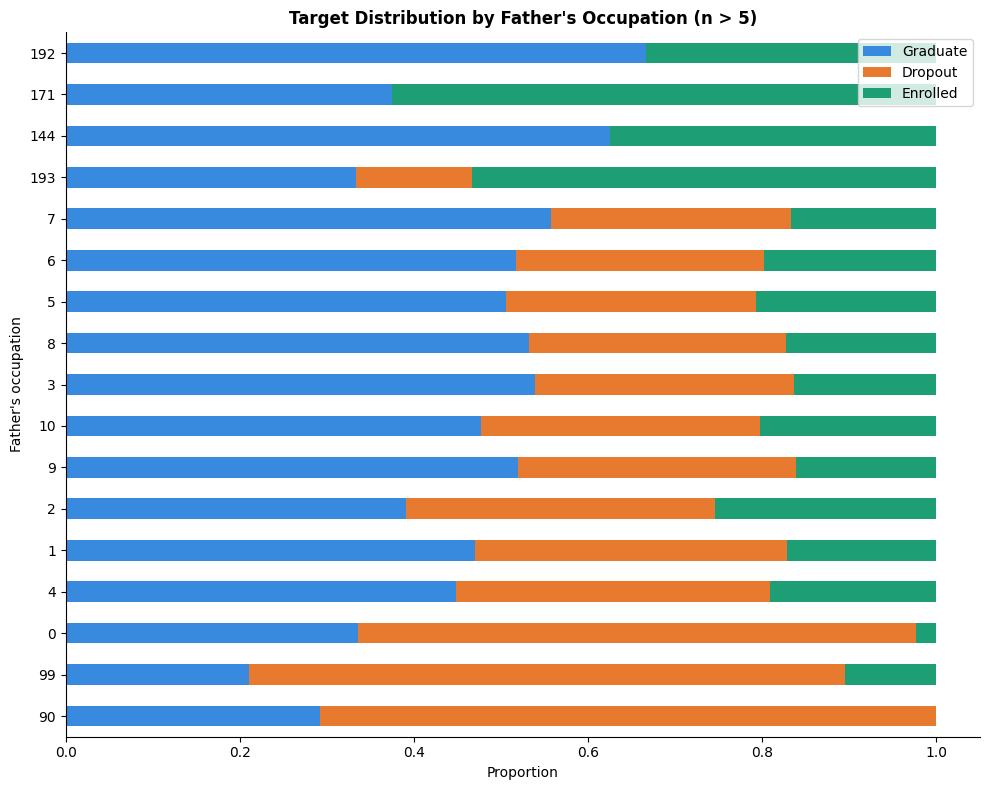

                     Graduate  Dropout  Enrolled     n
Father's occupation                                   
90                      0.292    0.708     0.000    65
99                      0.211    0.684     0.105    19
0                       0.336    0.641     0.023   128
4                       0.448    0.360     0.192   386
1                       0.470    0.358     0.172   134
2                       0.391    0.355     0.254   197
9                       0.519    0.320     0.161  1010
10                      0.477    0.320     0.203   266
3                       0.539    0.297     0.164   384
8                       0.531    0.296     0.173   318
5                       0.506    0.287     0.207   516
6                       0.517    0.285     0.198   242
7                       0.557    0.276     0.167   666
193                     0.333    0.133     0.533    15
144                     0.625    0.000     0.375     8
171                     0.375    0.000     0.625     8
192       

In [ ]:
course_target = (df.groupby("Father's occupation")["Target"].value_counts(normalize=True).unstack(fill_value=0))
course_target.columns = ["Graduate", "Dropout", "Enrolled"]
course_target["n"] = df.groupby("Father's occupation")["Target"].count()

course_target = course_target[course_target["n"] > 5]

course_target = course_target.sort_values("Dropout", ascending=False)

course_target.drop(columns="n").plot.barh(stacked=True, figsize=(10, 8), color=["#378ADD", "#E87A30", "#1D9E75"])
plt.title("Target Distribution by Father's Occupation (n > 5)", fontweight="bold")
plt.xlabel("Proportion")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(course_target.round(3).to_string())

/tmp/ipykernel_1850/4271998281.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_target = (df.groupby("Age Group")["Target"].value_counts(normalize=True).unstack(fill_value=0))


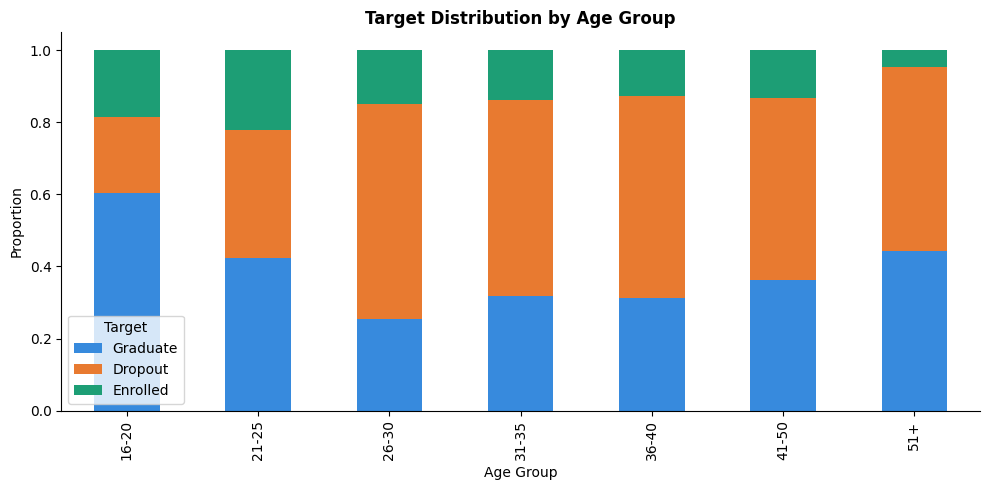

In [ ]:
bins = [15, 20, 25, 30, 35, 40, 50, 70]
labels = ["16-20", "21-25", "26-30", "31-35", "36-40", "41-50", "51+"]

df["Age Group"] = pd.cut(df["Age at enrollment"], bins=bins, labels=labels, right=True)

age_target = (df.groupby("Age Group")["Target"].value_counts(normalize=True).unstack(fill_value=0))

age_target.columns = ["Graduate", "Dropout", "Enrolled"]


age_target.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#378ADD", "#E87A30", "#1D9E75"])

plt.title("Target Distribution by Age Group", fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Proportion")
plt.legend(title="Target")

plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(columns=["Age Group"])

#Preprocessing

In [ ]:
mask = (df[['Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)']].mean(axis=1) == 0) & (df['Target'] == 0)
n_removed = mask.sum()
df = df.drop(df[mask].index)
print(f"Removed {n_removed} students with 0 approved units in both semesters (Graduates) — {len(df)} remaining")

Removed 75 students with 0 approved units in both semesters (Graduates) — 4349 remaining


we remove graduated student with grade equal to 0

### One-hot encoding

In [ ]:
THRESHOLD = 50

cat_cols = ["Course", "Father's occupation", "Father's qualification",
            "Mother's qualification", "Mother's occupation", "Application mode",
            "Marital status", "Nacionality", "Previous qualification"]

for col in cat_cols:
    counts = df[col].value_counts()
    rares = counts[counts < THRESHOLD].index
    df[col] = df[col].replace(rares, 99)
    print(f"{col}: {len(rares)} rare categories grouped → {df[col].nunique()} remaining")

X_enc = pd.get_dummies(df.drop(columns=["Target"]), columns=cat_cols, drop_first=True)
y = df["Target"].values
print(f"\nColumns after one-hot: {X_enc.shape[1]}")

Course: 1 rare categories grouped → 17 remaining
Father's occupation: 34 rare categories grouped → 13 remaining
Father's qualification: 27 rare categories grouped → 8 remaining
Mother's qualification: 22 rare categories grouped → 8 remaining
Mother's occupation: 22 rare categories grouped → 11 remaining
Application mode: 9 rare categories grouped → 10 remaining
Marital status: 3 rare categories grouped → 4 remaining
Nacionality: 20 rare categories grouped → 2 remaining
Previous qualification: 13 rare categories grouped → 5 remaining

Columns after one-hot: 96


Even though the categorical variables are already represented as integers in the dataset, they cannot be used as-is. Leaving them as numerical sequences would trick the model into assuming a mathematical order or ranking that does not exist.

Grouping low-frequency categories (fewer than 50 occurrences) under a single label is essential to prevent overfitting. Keeping extremely rare categories provides too little data for the model to learn meaningful patterns and unnecessarily inflates the dataset's dimensionality. Merging them stabilizes the model's predictions and simplifies the feature space.

# Variable selection Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

imp = pd.Series(rf.feature_importances_, index=X_train.columns)

/tmp/ipykernel_1850/1856379397.py:12: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


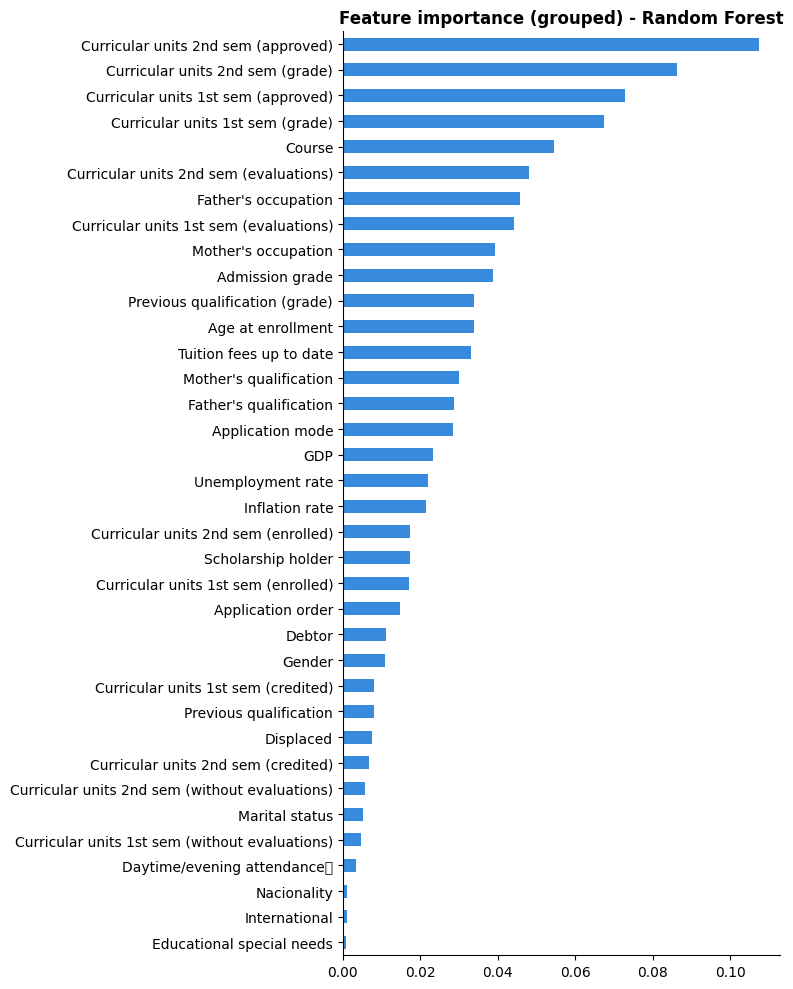

Curricular units 2nd sem (approved)               0.1075
Curricular units 2nd sem (grade)                  0.0863
Curricular units 1st sem (approved)               0.0729
Curricular units 1st sem (grade)                  0.0675
Course                                            0.0545
Curricular units 2nd sem (evaluations)            0.0481
Father's occupation                               0.0457
Curricular units 1st sem (evaluations)            0.0442
Mother's occupation                               0.0392
Admission grade                                   0.0387
Previous qualification (grade)                    0.0340
Age at enrollment                                 0.0340
Tuition fees up to date                           0.0330
Mother's qualification                            0.0300
Father's qualification                            0.0288
Application mode                                  0.0283
GDP                                               0.0232
Unemployment rate              

In [ ]:
def get_original(col):
    for cat in cat_cols:
        if col.startswith(cat + "_"):
            return cat
    return col

imp_grouped = imp.groupby(imp.index.map(get_original)).sum().sort_values()

imp_grouped.plot.barh(figsize=(8, 10), color="#378ADD")
plt.title("Feature importance (grouped) - Random Forest", fontweight="bold")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(imp_grouped.sort_values(ascending=False).round(4).to_string())

This figure shows us the importance of each variable in explaining the target for a random forest model. Some are nearly zero, so they should not be included in the predictive model, as they could simply reduce its performance while increasing computation time.

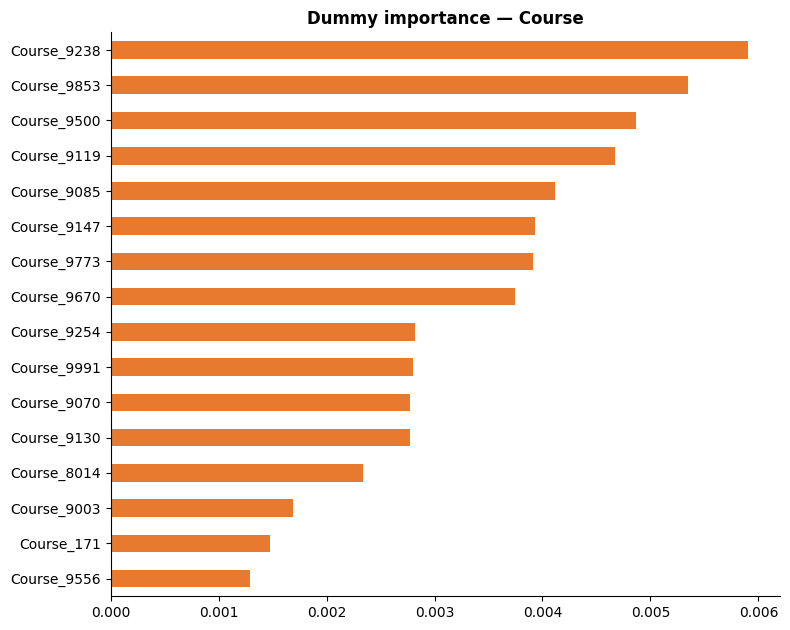

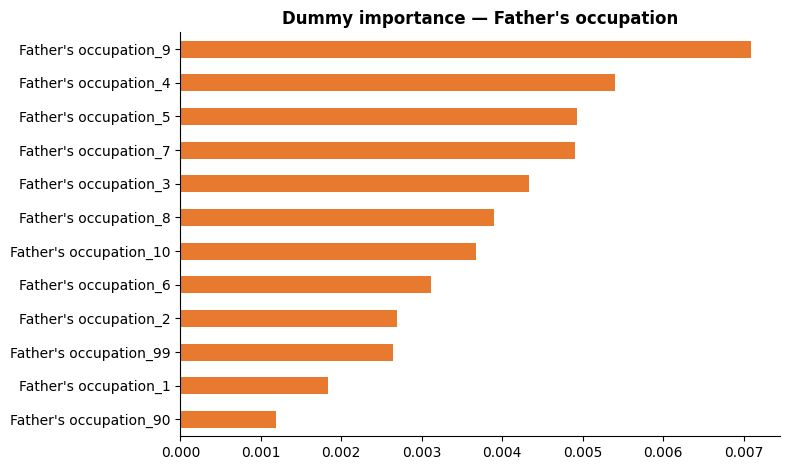

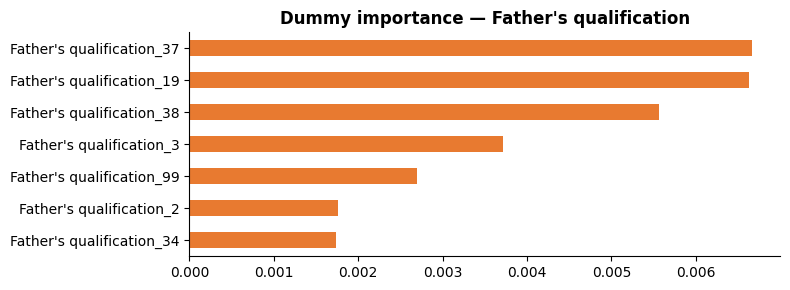

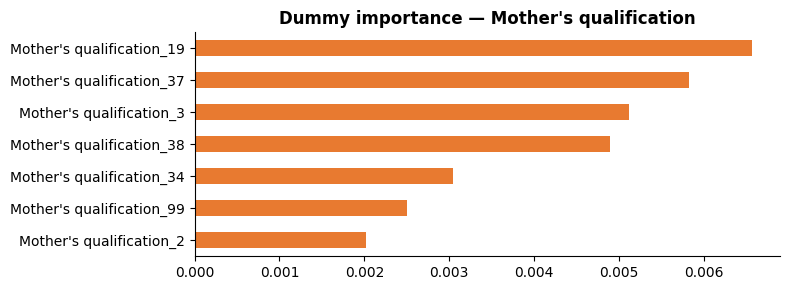

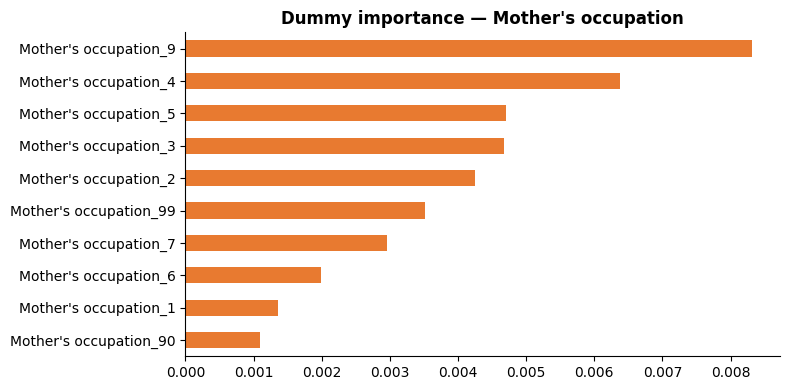

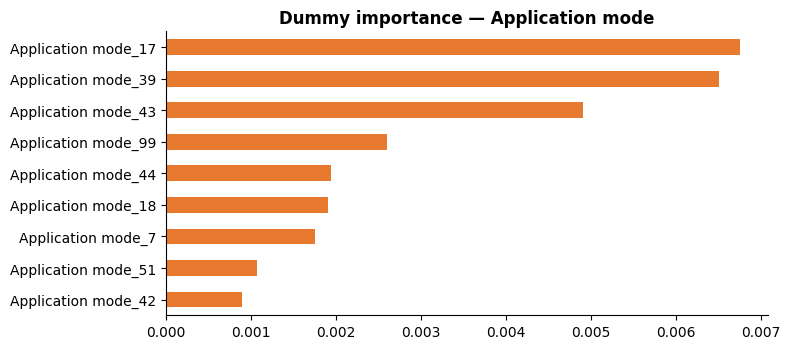

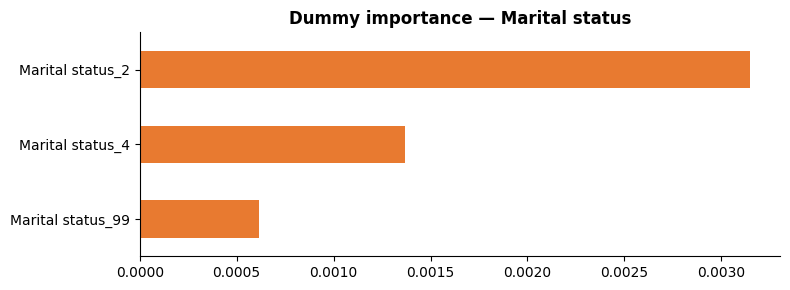

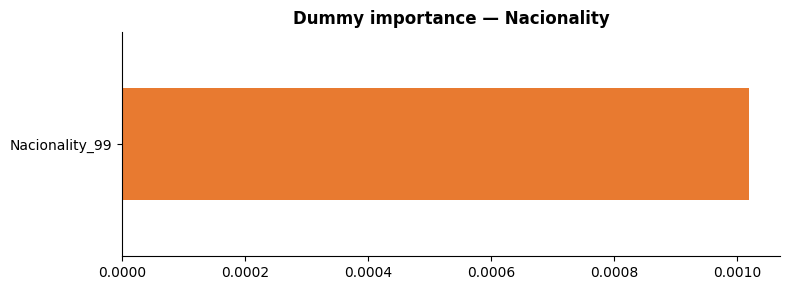

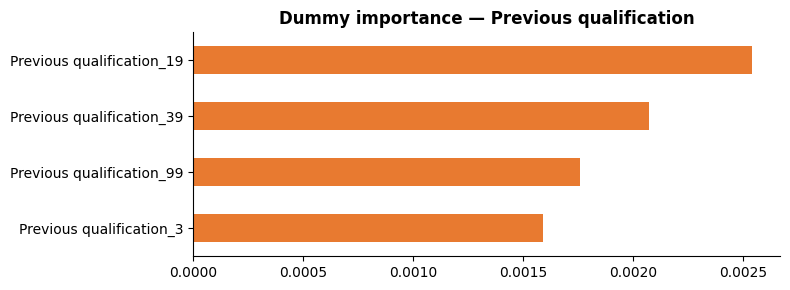

In [ ]:
for cat in cat_cols:
    dummies = [c for c in X_enc.columns if c.startswith(cat + "_")]
    if not dummies:
        continue
    imp[dummies].sort_values().plot.barh(figsize=(8, max(3, len(dummies)*0.4)), color="#E87A30")
    plt.title(f"Dummy importance — {cat}", fontweight="bold")
    plt.gca().spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

We see that some dummy variables are more important than other for all variable but there are no significant differences.

Top  1 features — CV: 0.6861 ± 0.0380
Top  2 features — CV: 0.6648 ± 0.0049
Top  3 features — CV: 0.6792 ± 0.0123
Top  4 features — CV: 0.6896 ± 0.0091
Top  5 features — CV: 0.7039 ± 0.0015
Top  6 features — CV: 0.7166 ± 0.0028
Top  7 features — CV: 0.7266 ± 0.0105
Top  8 features — CV: 0.7281 ± 0.0049
Top  9 features — CV: 0.7315 ± 0.0050
Top 10 features — CV: 0.7341 ± 0.0095
Top 11 features — CV: 0.7373 ± 0.0046
Top 12 features — CV: 0.7393 ± 0.0073
Top 13 features — CV: 0.7631 ± 0.0061
Top 14 features — CV: 0.7594 ± 0.0065
Top 15 features — CV: 0.7603 ± 0.0044
Top 16 features — CV: 0.7603 ± 0.0071
Top 17 features — CV: 0.7620 ± 0.0033
Top 18 features — CV: 0.7646 ± 0.0100
Top 19 features — CV: 0.7574 ± 0.0054
Top 20 features — CV: 0.7629 ± 0.0026
Top 21 features — CV: 0.7620 ± 0.0062
Top 22 features — CV: 0.7646 ± 0.0107
Top 23 features — CV: 0.7689 ± 0.0050
Top 24 features — CV: 0.7677 ± 0.0117
Top 25 features — CV: 0.7712 ± 0.0083
Top 26 features — CV: 0.7677 ± 0.0029
Top 27 featu

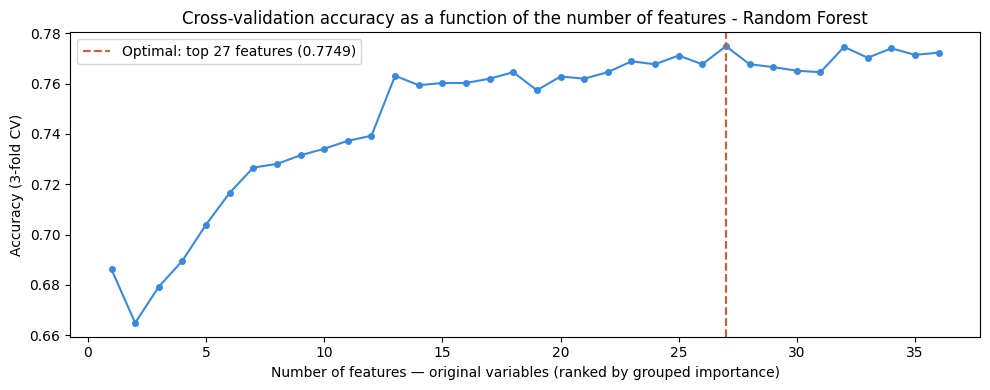


Best score   : 0.7749 with 27 features
All features : 0.7723

Top 27 optimal features:
['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Course', 'Curricular units 2nd sem (evaluations)', "Father's occupation", 'Curricular units 1st sem (evaluations)', "Mother's occupation", 'Admission grade', 'Previous qualification (grade)', 'Age at enrollment', 'Tuition fees up to date', "Mother's qualification", "Father's qualification", 'Application mode', 'GDP', 'Unemployment rate', 'Inflation rate', 'Curricular units 2nd sem (enrolled)', 'Scholarship holder', 'Curricular units 1st sem (enrolled)', 'Application order', 'Debtor', 'Gender', 'Curricular units 1st sem (credited)', 'Previous qualification']


In [ ]:
ranked_features = imp_grouped.sort_values(ascending=False).index.tolist()

scores = []
for n in range(1, len(ranked_features) + 1):
    top_n = ranked_features[:n]
    cols = [c for c in X_train.columns if get_original(c) in top_n]
    m = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
    cv = cross_val_score(m, X_train[cols], y_train, cv=3, scoring="accuracy")
    scores.append(cv.mean())
    print(f"Top {n:2d} features — CV: {cv.mean():.4f} ± {cv.std():.4f}")

best_n = np.argmax(scores) + 1

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(scores) + 1), scores, marker="o", markersize=4, color="#378ADD")
plt.axvline(best_n, color="#D85A30", linestyle="--",
            label=f"Optimal: top {best_n} features ({max(scores):.4f})")
plt.xlabel("Number of features — original variables (ranked by grouped importance)")
plt.ylabel("Accuracy (3-fold CV)")
plt.title("Cross-validation accuracy as a function of the number of features - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest score   : {max(scores):.4f} with {best_n} features")
print(f"All features : {scores[-1]:.4f}")
print(f"\nTop {best_n} optimal features:")
print(ranked_features[:best_n])

This figure shows that using only the 27 most important variables allows the model to achieve the best performance. Including all 36 available variables is counterproductive, as the model's accuracy decreases when the least important features are added.

In [ ]:
selected_orig = ranked_features[:best_n]
selected_cols = [c for c in X_enc.columns if get_original(c) in selected_orig]

print(f"Selected original variables ({len(selected_orig)}):")
for f in selected_orig:
    print(f"  - {f}")

Selected original variables (27):
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Course
  - Curricular units 2nd sem (evaluations)
  - Father's occupation
  - Curricular units 1st sem (evaluations)
  - Mother's occupation
  - Admission grade
  - Previous qualification (grade)
  - Age at enrollment
  - Tuition fees up to date
  - Mother's qualification
  - Father's qualification
  - Application mode
  - GDP
  - Unemployment rate
  - Inflation rate
  - Curricular units 2nd sem (enrolled)
  - Scholarship holder
  - Curricular units 1st sem (enrolled)
  - Application order
  - Debtor
  - Gender
  - Curricular units 1st sem (credited)
  - Previous qualification


We select the most important variables; these are our features.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train[selected_cols], y_train)
importance = pd.Series(rf.feature_importances_, index=selected_cols).sort_values(ascending=False)

THRESHOLD = 0.75
TOL = 0.005

def cv_score(cols):
    m = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
    return cross_val_score(m, X_train[cols], y_train, cv=3, scoring="accuracy").mean()

score_base = cv_score(selected_cols)
print(f"Initial score ({len(selected_orig)} variables / {len(selected_cols)} columns) : {score_base:.4f}\n")

remaining_cols = selected_cols.copy()
remaining_orig = selected_orig.copy()
retraits = []

for orig_a, orig_b in itertools.combinations(selected_orig, 2):
    if orig_a not in remaining_orig or orig_b not in remaining_orig:
        continue

    col_a = orig_a if orig_a in X_train.columns else [c for c in X_train.columns if c.startswith(orig_a + "_")][0]
    col_b = orig_b if orig_b in X_train.columns else [c for c in X_train.columns if c.startswith(orig_b + "_")][0]
    corr = abs(X_train[[col_a, col_b]].corr().iloc[0, 1])

    if corr < THRESHOLD:
        continue

    imp_a = importance[[c for c in remaining_cols if get_original(c) == orig_a]].sum()
    imp_b = importance[[c for c in remaining_cols if get_original(c) == orig_b]].sum()
    orig_retirer = orig_a if imp_a < imp_b else orig_b

    candidat_cols = [c for c in remaining_cols if get_original(c) != orig_retirer]
    score_sans = cv_score(candidat_cols)

    print(f"Correlation {corr:.2f} | {orig_a}  ↔  {orig_b}")
    print(f"  → Removed : {orig_retirer}")
    print(f"  → Score with : {score_base:.4f}  |  Score without : {score_sans:.4f}  |  Δ = {score_sans - score_base:+.4f}")

    if score_sans >= score_base - TOL:
        remaining_orig.remove(orig_retirer)
        remaining_cols = [c for c in remaining_cols if get_original(c) != orig_retirer]
        score_base = score_sans
        retraits.append(orig_retirer)
        print("  ✓ Removed\n")
    else:
        print("  ✗ Kept (excessive loss)\n")

print(f"Final variables ({len(remaining_orig)}) : {remaining_orig}")
print(f"Removed variables ({len(retraits)}) : {retraits}")
print(f"Final score : {score_base:.4f}")

selected_orig = remaining_orig
selected_cols = remaining_cols
X_final = X_train[selected_cols]

Initial score (27 variables / 85 columns) : 0.7749

Correlation 0.90 | Curricular units 2nd sem (approved)  ↔  Curricular units 1st sem (approved)
  → Removed : Curricular units 1st sem (approved)
  → Score with : 0.7749  |  Score without : 0.7643  |  Δ = -0.0106
  ✗ Kept (excessive loss)

Correlation 0.83 | Curricular units 2nd sem (grade)  ↔  Curricular units 1st sem (grade)
  → Removed : Curricular units 1st sem (grade)
  → Score with : 0.7749  |  Score without : 0.7721  |  Δ = -0.0029
  ✓ Removed

Correlation 0.77 | Curricular units 1st sem (approved)  ↔  Curricular units 1st sem (enrolled)
  → Removed : Curricular units 1st sem (enrolled)
  → Score with : 0.7721  |  Score without : 0.7761  |  Δ = +0.0040
  ✓ Removed

Correlation 0.77 | Curricular units 2nd sem (evaluations)  ↔  Curricular units 1st sem (evaluations)
  → Removed : Curricular units 1st sem (evaluations)
  → Score with : 0.7761  |  Score without : 0.7761  |  Δ = -0.0000
  ✓ Removed

Final variables (24) : ['Curricula

We remove variables that are too highly correlated. When two variables have a correlation coefficient that is too high, we keep the variable with the higher importance score. We then check that the model’s accuracy does not decrease too much after removing the variable. If the performance drops significantly, the variable is ultimately kept. This process allows us to further reduce the number of features used by the model, decreasing its complexity while slightly improving its performance.

This result is very strong after fine-tuning, indicating that the model achieves a high level of performance with well-optimized hyperparameters.

# Pipeline

In [ ]:
THRESHOLD_CORR = 0.75
TOL = 0.005
N_FOLDS = 5

def get_original(col):
    for cat in cat_cols:
        if col.startswith(cat + "_"):
            return cat
    return col

def remove_correlated(orig_vars, cols, X_fold, y_fold, imp_ref):
    """Retire les variables trop corrélées sur un fold donné."""
    remaining_orig = orig_vars.copy()
    remaining_cols = cols.copy()

    def cv_score_local(c):
        m = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
        return cross_val_score(m, X_fold[c], y_fold, cv=3, scoring="accuracy").mean()

    for orig_a, orig_b in itertools.combinations(orig_vars, 2):
        if orig_a not in remaining_orig or orig_b not in remaining_orig:
            continue
        col_a = orig_a if orig_a in X_fold.columns else [c for c in X_fold.columns if c.startswith(orig_a + "_")][0]
        col_b = orig_b if orig_b in X_fold.columns else [c for c in X_fold.columns if c.startswith(orig_b + "_")][0]
        corr = abs(X_fold[[col_a, col_b]].corr().iloc[0, 1])
        if corr < THRESHOLD_CORR:
            continue
        imp_a = imp_ref[[c for c in remaining_cols if get_original(c) == orig_a]].sum()
        imp_b = imp_ref[[c for c in remaining_cols if get_original(c) == orig_b]].sum()
        orig_retirer = orig_a if imp_a < imp_b else orig_b
        candidat = [c for c in remaining_cols if get_original(c) != orig_retirer]
        if cv_score_local(candidat) >= cv_score_local(remaining_cols) - TOL:
            remaining_orig.remove(orig_retirer)
            remaining_cols = candidat
    return remaining_orig, remaining_cols

In [ ]:
y = df["Target"].values
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_enc, y)):
    print(f"\n{'='*50}\nFOLD {fold+1}/{N_FOLDS}\n{'='*50}")
    X_train, X_test = X_enc.iloc[train_idx], X_enc.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 1. Importance grouped on train
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
    rf.fit(X_train, y_train)
    imp = pd.Series(rf.feature_importances_, index=X_train.columns)
    imp_grouped = imp.groupby(imp.index.map(get_original)).sum().sort_values(ascending=False)
    ranked_features = imp_grouped.index.tolist()

    # 2. Top N feature
    scores = []
    for n in range(1, len(ranked_features) + 1):
        top_n = ranked_features[:n]
        cols = [c for c in X_train.columns if get_original(c) in top_n]
        m = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
        cv = cross_val_score(m, X_train[cols], y_train, cv=3, scoring="accuracy")
        scores.append(cv.mean())
    best_n = np.argmax(scores) + 1
    selected_orig = ranked_features[:best_n]
    selected_cols = [c for c in X_train.columns if get_original(c) in selected_orig]
    print(f"Best N : {best_n} variables — CV score : {max(scores):.4f}")

    # 3. Removal of correlated variables
    imp_ref = imp[selected_cols]
    final_orig, final_cols = remove_correlated(selected_orig, selected_cols, X_train, y_train, imp_ref)
    print(f"After correlation removal : {len(final_orig)} variables")

    # 4. Final score on test
    rf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
    rf_final.fit(X_train[final_cols], y_train)
    score = rf_final.score(X_test[final_cols], y_test)
    print(f"Test accuracy : {score:.4f}")

    fold_results.append({
        "fold": fold + 1,
        "score": score,
        "selected_orig": final_orig,
        "selected_cols": final_cols,
        "n_features": len(final_orig)
    })


FOLD 1/5
Best N : 29 variables — CV score : 0.7838
After correlation removal : 26 variables
Test accuracy : 0.7828

FOLD 2/5
Best N : 36 variables — CV score : 0.7752
After correlation removal : 32 variables
Test accuracy : 0.7874

FOLD 3/5
Best N : 28 variables — CV score : 0.7833
After correlation removal : 24 variables
Test accuracy : 0.7862

FOLD 4/5
Best N : 29 variables — CV score : 0.7813
After correlation removal : 25 variables
Test accuracy : 0.7874

FOLD 5/5
Best N : 26 variables — CV score : 0.7761
After correlation removal : 22 variables
Test accuracy : 0.7675


In [ ]:
# Summary
print(f"\n{'='*50}")
print("RESULTS SUMMARY")
print(f"{'='*50}")
scores = [r["score"] for r in fold_results]
for r in fold_results:
    print(f"Fold {r['fold']} — {r['n_features']} variables — Accuracy: {r['score']:.4f}")
print(f"\nMean accuracy : {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Variables selected in each fold
all_orig = [f for r in fold_results for f in r["selected_orig"]]
feature_counts = Counter(all_orig)
print(f"\nFeature selection stability ({N_FOLDS} folds):")
for feat, count in feature_counts.most_common():
    bar = "█" * count
    print(f"  {count}/{N_FOLDS} {bar} {feat}")


RESULTS SUMMARY
Fold 1 — 26 variables — Accuracy: 0.7828
Fold 2 — 32 variables — Accuracy: 0.7874
Fold 3 — 24 variables — Accuracy: 0.7862
Fold 4 — 25 variables — Accuracy: 0.7874
Fold 5 — 22 variables — Accuracy: 0.7675

Mean accuracy : 0.7822 ± 0.0075

Feature selection stability (5 folds):
  5/5 █████ Curricular units 2nd sem (approved)
  5/5 █████ Course
  5/5 █████ Father's occupation
  5/5 █████ Admission grade
  5/5 █████ Mother's occupation
  5/5 █████ Age at enrollment
  5/5 █████ Previous qualification (grade)
  5/5 █████ Tuition fees up to date
  5/5 █████ Mother's qualification
  5/5 █████ Father's qualification
  5/5 █████ Application mode
  5/5 █████ GDP
  5/5 █████ Unemployment rate
  5/5 █████ Inflation rate
  5/5 █████ Application order
  5/5 █████ Scholarship holder
  5/5 █████ Debtor
  5/5 █████ Gender
  5/5 █████ Displaced
  4/5 ████ Curricular units 1st sem (approved)
  4/5 ████ Previous qualification
  4/5 ████ Curricular units 2nd sem (evaluations)
  3/5 ███ Cur

Stables features stables at least 3/4/5 folds

In [ ]:
stable_features_orig = [f for f, count in feature_counts.items() if count >= 3]
stable_features_cols = [c for c in X_enc.columns if get_original(c) in stable_features_orig]
X_final = X_enc[stable_features_cols]

print(f"Stable features ({len(stable_features_orig)}) : {stable_features_orig}")

Stable features (25) : ['Curricular units 2nd sem (approved)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Course', "Father's occupation", 'Admission grade', "Mother's occupation", 'Age at enrollment', 'Previous qualification (grade)', 'Tuition fees up to date', "Mother's qualification", "Father's qualification", 'Application mode', 'GDP', 'Unemployment rate', 'Inflation rate', 'Curricular units 2nd sem (enrolled)', 'Application order', 'Scholarship holder', 'Debtor', 'Gender', 'Displaced', 'Previous qualification', 'Curricular units 1st sem (credited)', 'Curricular units 2nd sem (evaluations)']


# Fine tuning Random Forest

### GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
y = df["Target"].values
X = X_final

param_grid = {
    "n_estimators"      : [300, 400],
    "max_depth"         : [None, 7, 15],
    "min_samples_split" : [6, 8, 12],
    "max_features"      : ["sqrt", "log2"],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)
grid.fit(X, y)

print(f"Best parameters : {grid.best_params_}")
print(f"Best score CV   : {grid.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 8, 'n_estimators': 400}
Best score CV   : 0.7896


# Error analysis

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
y = df["Target"].values

classes = {
    0: "Graduate",
    1: "Dropout",
    2: "Enrolled"
}

class_names = [classes[i] for i in sorted(classes.keys())]

y_true_all = np.zeros(len(y), dtype=int)
y_pred_all = np.zeros(len(y), dtype=int)

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y)):
    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf_final = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        **grid.best_params_
    )

    rf_final.fit(X_train, y_train)

    y_pred_all[test_idx] = rf_final.predict(X_test)
    y_true_all[test_idx] = y_test

print(f"Overall accuracy : {(y_true_all == y_pred_all).mean():.4f}")

### Classification Report

In [ ]:
print(classification_report(y_true_all, y_pred_all, target_names=class_names))

              precision    recall  f1-score   support

    Graduate       0.81      0.93      0.87      2134
     Dropout       0.84      0.77      0.80      1421
    Enrolled       0.58      0.45      0.50       794

    accuracy                           0.79      4349
   macro avg       0.74      0.72      0.72      4349
weighted avg       0.78      0.79      0.78      4349



The model achieves 79% accuracy with strong performance on Graduate (F1=0.87)
and decent results on Dropout (F1=0.80), but struggles significantly with
Enrolled students (F1=0.52). This is expected — enrolled students are still
in progress, making their outcome inherently ambiguous and hard to predict.
The macro F1 of 0.73 reflects this class imbalance in difficulty.

### Confusion Matrix

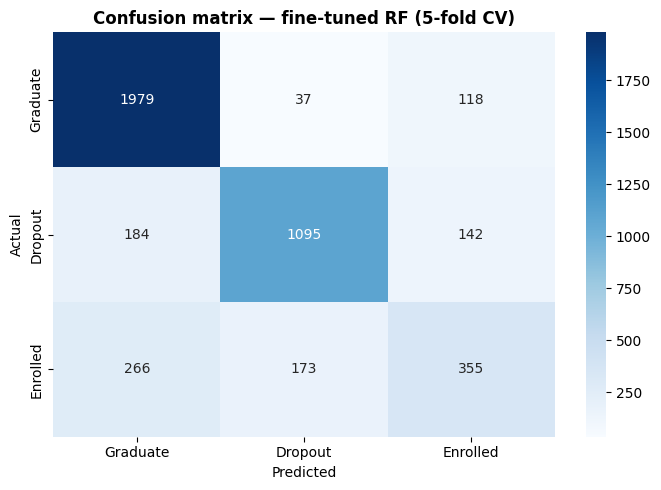

In [ ]:
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — fine-tuned RF (5-fold CV)", fontweight="bold")
plt.tight_layout()
plt.show()

The confusion matrix confirms that Graduate and Dropout students are well identified,
with most predictions falling on the diagonal. The main source of error is the
Enrolled class — the model systematically misclassifies enrolled students as either
Graduate or Dropout, which makes sense since enrolled students share academic
characteristics with both groups depending on their current progression.

### Error rate per class

In [ ]:
print("Error rate per class:")
for i, cls in classes.items():
    mask = y_true_all == i
    err = (y_pred_all[mask] != y_true_all[mask]).mean()
    print(f"  {cls:10s} : {err:.1%} errors")

Error rate per class:
  Graduate   : 7.3% errors
  Dropout    : 22.9% errors
  Enrolled   : 55.3% errors


This confirms the previous observations — Graduate students are almost perfectly
identified (7.5% error), Dropout detection is acceptable (23.4%) but Enrolled
remains the weakest class with over half misclassified (53.0%).

### Profile of misclassified students

In [ ]:
df_eval = df.copy()
df_eval["y_true"] = pd.Series(y_true_all).map(classes).values
df_eval["y_pred"] = pd.Series(y_pred_all).map(classes).values
df_eval["correct"] = df_eval["y_true"] == df_eval["y_pred"]

cat_vars = ["Course", "Father's occupation", "Father's qualification",
            "Mother's qualification", "Mother's occupation", "Application mode",
            "Marital status", "Nacionality", "Previous qualification",
            "Gender", "Scholarship holder", "Debtor", "Displaced", "Tuition fees up to date"]

num_vars = df_eval.drop(columns=["Target", "y_true", "y_pred", "correct"] + cat_vars)\
                  .select_dtypes(include="number").columns.tolist()

In [ ]:
print("=== NUMERICAL VARIABLES — mean by prediction outcome ===\n")
summary = df_eval.groupby("correct")[num_vars].mean().round(2).T.rename(
    columns={True: "Correctly predicted", False: "Incorrectly predicted"})
summary["Diff (%)"] = ((summary["Correctly predicted"] - summary["Incorrectly predicted"])
                       / summary["Incorrectly predicted"].abs() * 100).round(1)
print(summary.sort_values("Diff (%)", key=abs, ascending=False).to_string())

=== NUMERICAL VARIABLES — mean by prediction outcome ===

correct                                         Incorrectly predicted  Correctly predicted  Diff (%)
GDP                                                              0.04                -0.01    -125.0
International                                                    0.02                 0.03      50.0
Curricular units 1st sem (credited)                              0.93                 0.67     -28.0
Curricular units 1st sem (without evaluations)                   0.17                 0.13     -23.5
Curricular units 2nd sem (credited)                              0.68                 0.52     -23.5
Curricular units 2nd sem (without evaluations)                   0.18                 0.14     -22.2
Curricular units 2nd sem (evaluations)                           9.36                 7.89     -15.7
Curricular units 1st sem (evaluations)                           9.33                 8.20     -12.1
Curricular units 2nd sem (grade) 

Misclassified students tend to have more credited units (sem 1: 0.96 vs 0.66)
and more evaluations, suggesting they are academically active but the model
struggles to determine their final outcome — consistent with the Enrolled confusion.
Grades are also slightly lower for misclassified students across both semesters,
indicating borderline academic profiles that sit between Graduate and Dropout.
Macroeconomic variables (GDP, inflation, unemployment) show negligible differences,
confirming they play little role in prediction errors. Overall, the model makes
most mistakes on students with intermediate and ambiguous academic profiles.

In [ ]:
print("\n=== CATEGORICAL VARIABLES — error rate per category ===\n")
for col in cat_vars:
    err_by_cat = df_eval.groupby(col)["correct"].agg(
        error_rate=lambda x: (~x).mean(),
        n="count"
    ).round(3).sort_values("error_rate", ascending=False)
    print(f"--- {col} ---")
    print(err_by_cat.to_string())
    print()


=== CATEGORICAL VARIABLES — error rate per category ===

--- Course ---
        error_rate    n
Course                 
9853         0.339  192
99           0.333   12
9119         0.306  170
171          0.264  140
9147         0.263  380
9130         0.262  141
9070         0.239  226
9991         0.235  268
9670         0.224  268
9556         0.221   86
9085         0.217  337
9773         0.208  331
9254         0.206  252
9003         0.195  210
8014         0.167  215
9500         0.144  766
9238         0.135  355

--- Father's occupation ---
                     error_rate    n
Father's occupation                 
99                        0.268  112
10                        0.262  260
4                         0.246  382
3                         0.232  371
2                         0.220  191
6                         0.212  241
5                         0.211  507
9                         0.208  996
7                         0.195  655
8                         0.187  31

# Variable selection Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

/tmp/ipykernel_1177/34212022.py:12: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


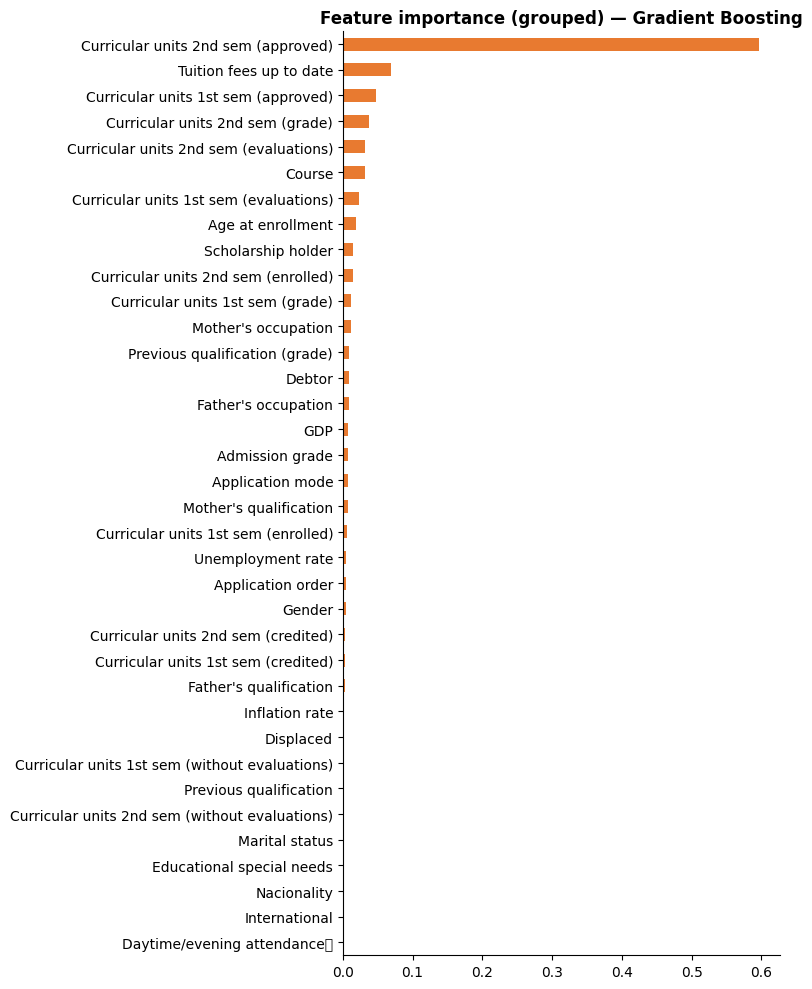

Curricular units 2nd sem (approved)               0.5968
Tuition fees up to date                           0.0687
Curricular units 1st sem (approved)               0.0478
Curricular units 2nd sem (grade)                  0.0372
Curricular units 2nd sem (evaluations)            0.0323
Course                                            0.0321
Curricular units 1st sem (evaluations)            0.0226
Age at enrollment                                 0.0193
Scholarship holder                                0.0148
Curricular units 2nd sem (enrolled)               0.0142
Curricular units 1st sem (grade)                  0.0112
Mother's occupation                               0.0111
Previous qualification (grade)                    0.0089
Debtor                                            0.0087
Father's occupation                               0.0082
GDP                                               0.0080
Admission grade                                   0.0075
Application mode               

In [ ]:
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train_gb, y_train_gb)
imp_gb = pd.Series(gb.feature_importances_, index=X_enc.columns)
imp_grouped_gb = imp_gb.groupby(imp_gb.index.map(get_original)).sum().sort_values()

imp_grouped_gb.plot.barh(figsize=(8, 10), color="#E87A30")
plt.title("Feature importance (grouped) — Gradient Boosting", fontweight="bold")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(imp_grouped_gb.sort_values(ascending=False).round(4).to_string())

In [ ]:
ranked_features_gb = imp_grouped_gb.sort_values(ascending=False).index.tolist()

scores_gb = []
for n in range(1, len(ranked_features_gb) + 1):
    top_n = ranked_features_gb[:n]
    cols = [c for c in X_train_gb.columns if get_original(c) in top_n]
    m = GradientBoostingClassifier(n_estimators=50, random_state=42)
    cv = cross_val_score(m, X_train_gb[cols], y_train_gb, cv=3, scoring="accuracy")
    scores_gb.append(cv.mean())
    print(f"Top {n:2d} features — CV: {cv.mean():.4f} ± {cv.std():.4f}")

best_n_gb = np.argmax(scores_gb) + 1

Top  1 features — CV: 0.7232 ± 0.0052
Top  2 features — CV: 0.7416 ± 0.0039
Top  3 features — CV: 0.7551 ± 0.0088
Top  4 features — CV: 0.7488 ± 0.0040
Top  5 features — CV: 0.7479 ± 0.0050
Top  6 features — CV: 0.7608 ± 0.0043
Top  7 features — CV: 0.7617 ± 0.0061
Top  8 features — CV: 0.7646 ± 0.0075
Top  9 features — CV: 0.7637 ± 0.0038
Top 10 features — CV: 0.7669 ± 0.0056
Top 11 features — CV: 0.7672 ± 0.0050
Top 12 features — CV: 0.7654 ± 0.0075
Top 13 features — CV: 0.7669 ± 0.0089
Top 14 features — CV: 0.7695 ± 0.0061
Top 15 features — CV: 0.7695 ± 0.0078
Top 16 features — CV: 0.7712 ± 0.0060
Top 17 features — CV: 0.7692 ± 0.0046
Top 18 features — CV: 0.7654 ± 0.0069
Top 19 features — CV: 0.7706 ± 0.0080
Top 20 features — CV: 0.7712 ± 0.0054
Top 21 features — CV: 0.7732 ± 0.0101
Top 22 features — CV: 0.7732 ± 0.0081
Top 23 features — CV: 0.7741 ± 0.0074
Top 24 features — CV: 0.7698 ± 0.0044
Top 25 features — CV: 0.7718 ± 0.0037
Top 26 features — CV: 0.7686 ± 0.0061
Top 27 featu

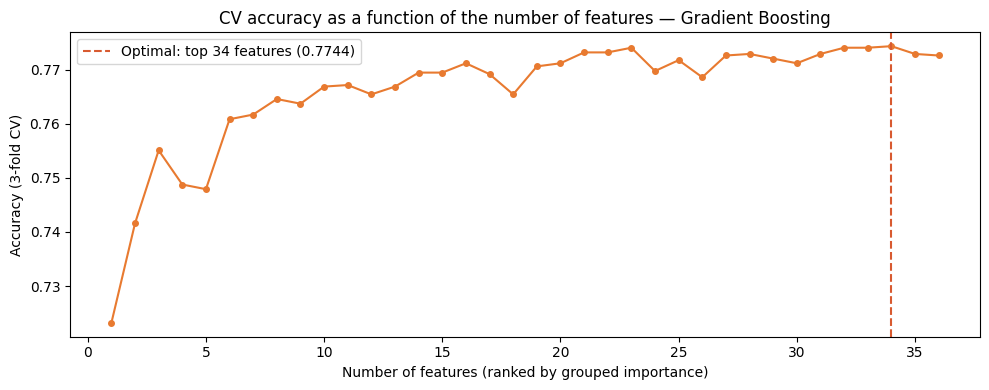


Best score   : 0.7744 with 34 features
All features : 0.7726

Top 34 optimal features:
['Curricular units 2nd sem (approved)', 'Tuition fees up to date', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (evaluations)', 'Course', 'Curricular units 1st sem (evaluations)', 'Age at enrollment', 'Scholarship holder', 'Curricular units 2nd sem (enrolled)', 'Curricular units 1st sem (grade)', "Mother's occupation", 'Previous qualification (grade)', 'Debtor', "Father's occupation", 'GDP', 'Admission grade', 'Application mode', "Mother's qualification", 'Curricular units 1st sem (enrolled)', 'Unemployment rate', 'Application order', 'Gender', 'Curricular units 2nd sem (credited)', 'Curricular units 1st sem (credited)', "Father's qualification", 'Inflation rate', 'Displaced', 'Curricular units 1st sem (without evaluations)', 'Previous qualification', 'Curricular units 2nd sem (without evaluations)', 'Marital status', 'Educational special needs

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(scores_gb) + 1), scores_gb, marker="o", markersize=4, color="#E87A30")
plt.axvline(best_n_gb, color="#D85A30", linestyle="--",
            label=f"Optimal: top {best_n_gb} features ({max(scores_gb):.4f})")
plt.xlabel("Number of features (ranked by grouped importance)")
plt.ylabel("Accuracy (3-fold CV)")
plt.title("CV accuracy as a function of the number of features — Gradient Boosting")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest score   : {max(scores_gb):.4f} with {best_n_gb} features")
print(f"All features : {scores_gb[-1]:.4f}")
print(f"\nTop {best_n_gb} optimal features:")
print(ranked_features_gb[:best_n_gb])

Generally, the Gradient Boosting method requires fewer variable than random forest to make good predictions.

In [ ]:
selected_orig_gb = ranked_features_gb[:best_n_gb]
selected_cols_gb = [c for c in X_train_gb.columns if get_original(c) in selected_orig_gb]

rf_gb = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train_gb[selected_cols_gb], y_train_gb)
importance_gb = pd.Series(rf_gb.feature_importances_, index=selected_cols_gb).sort_values(ascending=False)

THRESHOLD = 0.75
TOL = 0.005

def cv_score_gb(cols):
    m = GradientBoostingClassifier(n_estimators=50, random_state=42)
    return cross_val_score(m, X_train_gb[cols], y_train_gb, cv=3, scoring="accuracy").mean()

score_base = cv_score_gb(selected_cols_gb)
print(f"Initial score ({len(selected_orig_gb)} variables / {len(selected_cols_gb)} columns) : {score_base:.4f}\n")

remaining_cols_gb = selected_cols_gb.copy()
remaining_orig_gb = selected_orig_gb.copy()
retraits_gb = []

for orig_a, orig_b in itertools.combinations(selected_orig_gb, 2):
    if orig_a not in remaining_orig_gb or orig_b not in remaining_orig_gb:
        continue

    col_a = orig_a if orig_a in X_train_gb.columns else [c for c in X_train_gb.columns if c.startswith(orig_a + "_")][0]
    col_b = orig_b if orig_b in X_train_gb.columns else [c for c in X_train_gb.columns if c.startswith(orig_b + "_")][0]
    corr = abs(X_train_gb[[col_a, col_b]].corr().iloc[0, 1])

    if corr < THRESHOLD:
        continue

    imp_a = importance_gb[[c for c in remaining_cols_gb if get_original(c) == orig_a]].sum()
    imp_b = importance_gb[[c for c in remaining_cols_gb if get_original(c) == orig_b]].sum()
    orig_retirer = orig_a if imp_a < imp_b else orig_b

    candidat_cols = [c for c in remaining_cols_gb if get_original(c) != orig_retirer]
    score_sans = cv_score_gb(candidat_cols)

    print(f"Correlation {corr:.2f} | {orig_a}  ↔  {orig_b}")
    print(f"  → Removed : {orig_retirer}")
    print(f"  → Score with : {score_base:.4f}  |  Score without : {score_sans:.4f}  |  Δ = {score_sans - score_base:+.4f}")

    if score_sans >= score_base - TOL:
        remaining_orig_gb.remove(orig_retirer)
        remaining_cols_gb = [c for c in remaining_cols_gb if get_original(c) != orig_retirer]
        score_base = score_sans
        retraits_gb.append(orig_retirer)
        print("  ✓ Removed\n")
    else:
        print("  ✗ Kept (excessive loss)\n")

print(f"Final variables ({len(remaining_orig_gb)}) : {remaining_orig_gb}")
print(f"Removed variables ({len(retraits_gb)}) : {retraits_gb}")
print(f"Final score : {score_base:.4f}")

selected_orig_gb = remaining_orig_gb
selected_cols_gb = remaining_cols_gb
X_final_gb_exp = X_train_gb[selected_cols_gb]

Initial score (34 variables / 94 columns) : 0.7744

Correlation 0.90 | Curricular units 2nd sem (approved)  ↔  Curricular units 1st sem (approved)
  → Removed : Curricular units 1st sem (approved)
  → Score with : 0.7744  |  Score without : 0.7626  |  Δ = -0.0118
  ✗ Kept (excessive loss)

Correlation 0.77 | Curricular units 1st sem (approved)  ↔  Curricular units 1st sem (enrolled)
  → Removed : Curricular units 1st sem (enrolled)
  → Score with : 0.7744  |  Score without : 0.7712  |  Δ = -0.0032
  ✓ Removed

Correlation 0.83 | Curricular units 2nd sem (grade)  ↔  Curricular units 1st sem (grade)
  → Removed : Curricular units 1st sem (grade)
  → Score with : 0.7712  |  Score without : 0.7744  |  Δ = +0.0032
  ✓ Removed

Correlation 0.77 | Curricular units 2nd sem (evaluations)  ↔  Curricular units 1st sem (evaluations)
  → Removed : Curricular units 1st sem (evaluations)
  → Score with : 0.7744  |  Score without : 0.7709  |  Δ = -0.0034
  ✓ Removed

Correlation 0.95 | Curricular unit

# Pipeline

In [ ]:
THRESHOLD_CORR = 0.75
TOL = 0.005
N_FOLDS = 5

def remove_correlated_gb(orig_vars, cols, X_fold, y_fold, imp_ref):
    remaining_orig = orig_vars.copy()
    remaining_cols = cols.copy()

    def cv_score_local(c):
        m = GradientBoostingClassifier(n_estimators=50, random_state=42)
        return cross_val_score(m, X_fold[c], y_fold, cv=3, scoring="accuracy").mean()

    for orig_a, orig_b in itertools.combinations(orig_vars, 2):
        if orig_a not in remaining_orig or orig_b not in remaining_orig:
            continue
        col_a = orig_a if orig_a in X_fold.columns else [c for c in X_fold.columns if c.startswith(orig_a + "_")][0]
        col_b = orig_b if orig_b in X_fold.columns else [c for c in X_fold.columns if c.startswith(orig_b + "_")][0]
        corr = abs(X_fold[[col_a, col_b]].corr().iloc[0, 1])
        if corr < THRESHOLD_CORR:
            continue
        imp_a = imp_ref[[c for c in remaining_cols if get_original(c) == orig_a]].sum()
        imp_b = imp_ref[[c for c in remaining_cols if get_original(c) == orig_b]].sum()
        orig_retirer = orig_a if imp_a < imp_b else orig_b
        candidat = [c for c in remaining_cols if get_original(c) != orig_retirer]
        if cv_score_local(candidat) >= cv_score_local(remaining_cols) - TOL:
            remaining_orig.remove(orig_retirer)
            remaining_cols = candidat
    return remaining_orig, remaining_cols

In [ ]:
y = df["Target"].values
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results_gb = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_enc, y)):
    print(f"\n{'='*50}\nFOLD {fold+1}/{N_FOLDS}\n{'='*50}")
    X_train, X_test = X_enc.iloc[train_idx], X_enc.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 1. Importance grouped on train
    gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
    gb.fit(X_train, y_train)
    imp = pd.Series(gb.feature_importances_, index=X_train.columns)
    imp_grouped = imp.groupby(imp.index.map(get_original)).sum().sort_values(ascending=False)
    ranked = imp_grouped.index.tolist()

    # 2. top N features
    scores = []
    for n in range(1, len(ranked) + 1):
        top_n = ranked[:n]
        cols = [c for c in X_train.columns if get_original(c) in top_n]
        m = GradientBoostingClassifier(n_estimators=50, random_state=42)
        cv = cross_val_score(m, X_train[cols], y_train, cv=3, scoring="accuracy")
        scores.append(cv.mean())
    best_n = np.argmax(scores) + 1
    selected_orig = ranked[:best_n]
    selected_cols = [c for c in X_train.columns if get_original(c) in selected_orig]
    print(f"Best N : {best_n} variables — CV score : {max(scores):.4f}")

    # 3. Removal of correlated variables
    imp_ref = imp[selected_cols]
    final_orig, final_cols = remove_correlated_gb(selected_orig, selected_cols, X_train, y_train, imp_ref)
    print(f"After correlation removal : {len(final_orig)} variables")

    # 4. Score on test
    gb_final = GradientBoostingClassifier(n_estimators=100, random_state=42)
    gb_final.fit(X_train[final_cols], y_train)
    score = gb_final.score(X_test[final_cols], y_test)
    print(f"Test accuracy : {score:.4f}")

    fold_results_gb.append({
        "fold": fold + 1,
        "score": score,
        "selected_orig_before": selected_orig,
        "selected_orig": final_orig,
        "selected_cols": final_cols,
        "n_features": len(final_orig)
    })


FOLD 1/5
Best N : 21 variables — CV score : 0.7758
After correlation removal : 19 variables
Test accuracy : 0.7770

FOLD 2/5
Best N : 36 variables — CV score : 0.7758
After correlation removal : 31 variables
Test accuracy : 0.7839

FOLD 3/5
Best N : 34 variables — CV score : 0.7784
After correlation removal : 29 variables
Test accuracy : 0.7793

FOLD 4/5
Best N : 26 variables — CV score : 0.7792
After correlation removal : 22 variables
Test accuracy : 0.7747

FOLD 5/5
Best N : 27 variables — CV score : 0.7747
After correlation removal : 23 variables
Test accuracy : 0.7871


In [ ]:
# Summary
print(f"\n{'='*50}\nRESULTS SUMMARY\n{'='*50}")
scores_folds = [r["score"] for r in fold_results_gb]
for r in fold_results_gb:
    print(f"Fold {r['fold']} — {r['n_features']} variables — Accuracy: {r['score']:.4f}")
print(f"\nMean accuracy : {np.mean(scores_folds):.4f} ± {np.std(scores_folds):.4f}")

all_orig_gb = [f for r in fold_results_gb for f in r["selected_orig"]]
feature_counts_gb = Counter(all_orig_gb)
print(f"\nFeature selection stability ({N_FOLDS} folds):")
for feat, count in feature_counts_gb.most_common():
    bar = "█" * count
    print(f"  {count}/{N_FOLDS} {bar} {feat}")


RESULTS SUMMARY
Fold 1 — 19 variables — Accuracy: 0.7770
Fold 2 — 31 variables — Accuracy: 0.7839
Fold 3 — 29 variables — Accuracy: 0.7793
Fold 4 — 22 variables — Accuracy: 0.7747
Fold 5 — 23 variables — Accuracy: 0.7871

Mean accuracy : 0.7804 ± 0.0045

Feature selection stability (5 folds):
  5/5 █████ Curricular units 2nd sem (approved)
  5/5 █████ Tuition fees up to date
  5/5 █████ Course
  5/5 █████ Age at enrollment
  5/5 █████ Curricular units 2nd sem (enrolled)
  5/5 █████ Mother's occupation
  5/5 █████ Admission grade
  5/5 █████ GDP
  5/5 █████ Scholarship holder
  5/5 █████ Previous qualification (grade)
  5/5 █████ Father's occupation
  5/5 █████ Father's qualification
  5/5 █████ Debtor
  5/5 █████ Application mode
  5/5 █████ Mother's qualification
  4/5 ████ Curricular units 1st sem (approved)
  4/5 ████ Curricular units 2nd sem (credited)
  4/5 ████ Unemployment rate
  4/5 ████ Application order
  4/5 ████ Inflation rate
  3/5 ███ Curricular units 1st sem (grade)
  3

In [ ]:
# Stable features
SEUIL_STABILITE = 3
stable_features_orig_gb = [f for f, count in feature_counts_gb.items() if count >= SEUIL_STABILITE]
stable_features_cols_gb = [c for c in X_enc.columns if get_original(c) in stable_features_orig_gb]
X_final_gb = X_enc[stable_features_cols_gb]

print(f"\nStable features (≥{SEUIL_STABILITE}/{N_FOLDS} folds) : {len(stable_features_orig_gb)}")
for f in stable_features_orig_gb:
    print(f"  {feature_counts_gb[f]}/{N_FOLDS}  {f}")
print(f"\nX_final_gb shape : {X_final_gb.shape}")


Stable features (≥3/5 folds) : 23
  5/5  Curricular units 2nd sem (approved)
  5/5  Tuition fees up to date
  4/5  Curricular units 1st sem (approved)
  5/5  Course
  5/5  Age at enrollment
  5/5  Curricular units 2nd sem (enrolled)
  3/5  Curricular units 1st sem (grade)
  5/5  Mother's occupation
  5/5  Admission grade
  5/5  GDP
  5/5  Scholarship holder
  5/5  Previous qualification (grade)
  5/5  Father's occupation
  5/5  Father's qualification
  5/5  Debtor
  5/5  Application mode
  4/5  Curricular units 2nd sem (credited)
  5/5  Mother's qualification
  3/5  Curricular units 2nd sem (evaluations)
  4/5  Unemployment rate
  4/5  Application order
  4/5  Inflation rate
  3/5  Gender

X_final_gb shape : (4349, 78)


# Fine-Tuning

### Grid search

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
y = df["Target"].values
X = X_final_gb

param_grid_gb = {
    "n_estimators"      : [97, 100],
    "max_depth"         : [5, 7, 10],
    "learning_rate"     : [0.05, 0.08, 0.1],
    "min_samples_split" : [10, 13],
    "max_features"      : ["sqrt"],
    "subsample"         : [1.0],
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=5, scoring="accuracy",
    n_jobs=-1, verbose=1
)
grid_gb.fit(X, y)

print(f"Best parameters : {grid_gb.best_params_}")
print(f"Best score CV   : {grid_gb.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters : {'learning_rate': 0.08, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 97, 'subsample': 1.0}
Best score CV   : 0.7924


# Error analysis

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

Overall accuracy : 0.7896

              precision    recall  f1-score   support

    Graduate       0.81      0.94      0.87      2134
     Dropout       0.83      0.79      0.81      1421
    Enrolled       0.59      0.40      0.48       794

    accuracy                           0.79      4349
   macro avg       0.74      0.71      0.72      4349
weighted avg       0.78      0.79      0.78      4349



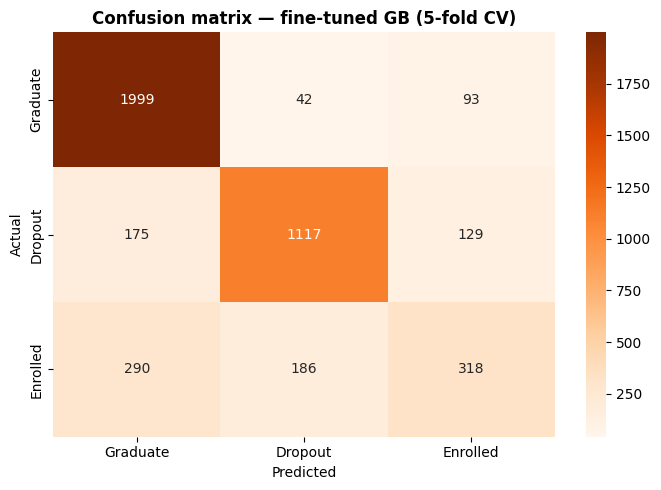


Error rate per class:
  Graduate   : 6.3% errors
  Dropout    : 21.4% errors
  Enrolled   : 59.9% errors


In [ ]:
y = df["Target"].values
classes = {0: "Graduate", 1: "Dropout", 2: "Enrolled"}
class_names = [classes[i] for i in sorted(classes.keys())]

y_true_all_gb = np.zeros(len(y), dtype=int)
y_pred_all_gb = np.zeros(len(y), dtype=int)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
for fold, (train_idx, test_idx) in enumerate(skf.split(X_final_gb, y)):
    X_train, X_test = X_final_gb.iloc[train_idx], X_final_gb.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    gb_final = GradientBoostingClassifier(random_state=42, **grid_gb.best_params_)
    gb_final.fit(X_train, y_train)
    y_pred_all_gb[test_idx] = gb_final.predict(X_test)
    y_true_all_gb[test_idx] = y_test

print(f"Overall accuracy : {(y_true_all_gb == y_pred_all_gb).mean():.4f}\n")
print(classification_report(y_true_all_gb, y_pred_all_gb, target_names=class_names))

cm = confusion_matrix(y_true_all_gb, y_pred_all_gb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — fine-tuned GB (5-fold CV)", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nError rate per class:")
for i, cls in classes.items():
    mask = y_true_all_gb == i
    err = (y_pred_all_gb[mask] != y_true_all_gb[mask]).mean()
    print(f"  {cls:10s} : {err:.1%} errors")

# Random Forest vs Gradient Boosting

### Comparison of confusion matrices

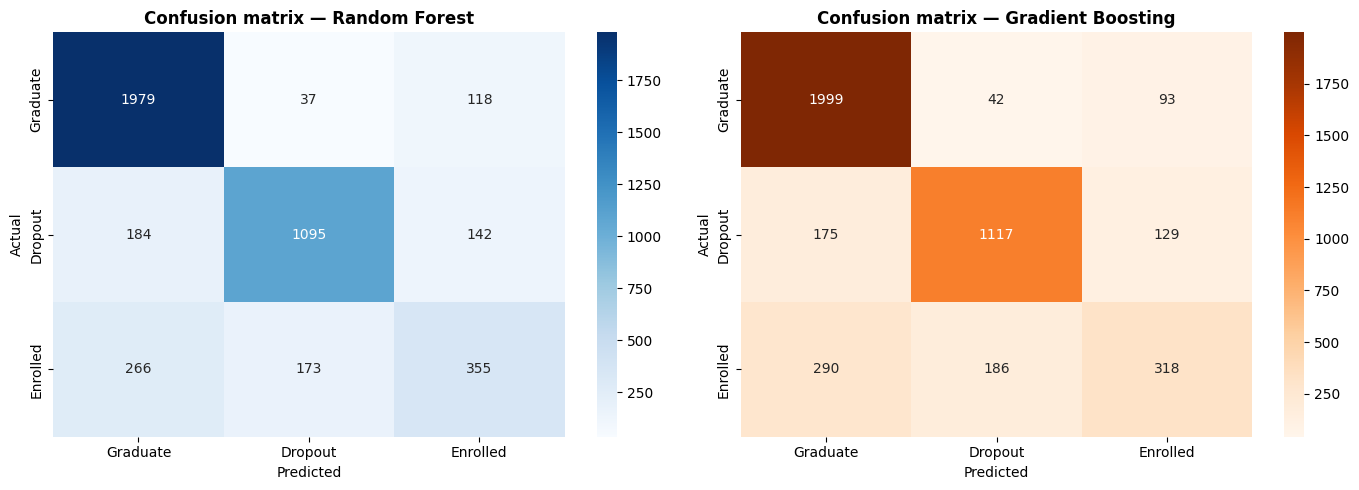

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_true_all, y_pred_all)
cm_gb = confusion_matrix(y_true_all_gb, y_pred_all_gb)

for ax, cm, title, cmap in zip(axes,
    [cm_rf, cm_gb],
    ["Random Forest", "Gradient Boosting"],
    ["Blues", "Oranges"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion matrix — {title}", fontweight="bold")

plt.tight_layout()
plt.show()

Both models demonstrate a strong ability to classify the two majority classes Graduates and Dropouts, but Gradient Boosting yields the best peak results in both.

The intermediate "Enrolled" status represents the main challenge for both models. However, Random Forest handles this specific class better, correctly identifying 373 enrolled students compared to only 311 for Gradient Boosting.

A closer look at the misclassifications reveals that for both models, the majority of errors stem from Enrolled students being wrongly predicted as Graduates, with Gradient Boosting committing more of these errors (295 vs. 256). This is followed by Enrolled students being misclassified as Dropouts, where Gradient Boosting again struggles more (188 vs. 165). Conversely, when it comes to Dropouts being falsely predicted as Graduates, Random Forest is the one making more mistakes (185 vs. 180).

### Comparison of error rates by class

In [ ]:
print(f"{'Class':12s} {'RF errors':>12} {'GB errors':>12} {'Winner':>10}")
print("-"*48)
for i, cls in classes.items():
    err_rf = (y_pred_all[y_true_all == i] != y_true_all[y_true_all == i]).mean()
    err_gb = (y_pred_all_gb[y_true_all_gb == i] != y_true_all_gb[y_true_all_gb == i]).mean()
    winner = "RF" if err_rf < err_gb else "GB"
    print(f"{cls:12s} {err_rf:>11.1%} {err_gb:>11.1%} {winner:>10}")

Class           RF errors    GB errors     Winner
------------------------------------------------
Graduate            7.3%        6.3%         GB
Dropout            22.9%       21.4%         GB
Enrolled           55.3%       59.9%         RF


Gradient Boosting performs best on the majority classes. Random Forest handles the minority Enrolled class better. Both models heavily struggle with the Enrolled category.

### Comparison of feature stability

In [ ]:
all_feats = sorted(set(list(feature_counts.keys()) + list(feature_counts_gb.keys())))

print(f"{'Feature':<45} {'RF':>6} {'GB':>6}")
print("-"*58)
for feat in sorted(all_feats, key=lambda x: -feature_counts.get(x, 0)):
    rf_count = feature_counts.get(feat, 0)
    gb_count = feature_counts_gb.get(feat, 0)
    print(f"  {feat:<43} {rf_count:>3}/{N_FOLDS}  {gb_count:>3}/{N_FOLDS}")

Feature                                           RF     GB
----------------------------------------------------------
  Admission grade                               5/5    5/5
  Age at enrollment                             5/5    5/5
  Application mode                              5/5    5/5
  Application order                             5/5    4/5
  Course                                        5/5    5/5
  Curricular units 2nd sem (approved)           5/5    5/5
  Debtor                                        5/5    5/5
  Displaced                                     5/5    2/5
  Father's occupation                           5/5    5/5
  Father's qualification                        5/5    5/5
  GDP                                           5/5    5/5
  Gender                                        5/5    3/5
  Inflation rate                                5/5    4/5
  Mother's occupation                           5/5    5/5
  Mother's qualification                        5/5    

Comparison of final features

In [ ]:
rf_feats = set(stable_features_orig)
gb_feats = set(stable_features_orig_gb)

common    = rf_feats & gb_feats
rf_only   = rf_feats - gb_feats
gb_only   = gb_feats - rf_feats

print(f"{'='*55}")
print(f"  Common features ({len(common)})")
print(f"{'='*55}")
for f in sorted(common):
    print(f"  ✓  {f}")

print(f"\n{'='*55}")
print(f"  RF only ({len(rf_only)})")
print(f"{'='*55}")
for f in sorted(rf_only):
    print(f"  →  {f}")

print(f"\n{'='*55}")
print(f"  GB only ({len(gb_only)})")
print(f"{'='*55}")
for f in sorted(gb_only):
    print(f"  →  {f}")

print(f"\nSummary : {len(common)} common / {len(rf_only)} RF only / {len(gb_only)} GB only")

  Common features (22)
  ✓  Admission grade
  ✓  Age at enrollment
  ✓  Application mode
  ✓  Application order
  ✓  Course
  ✓  Curricular units 1st sem (approved)
  ✓  Curricular units 1st sem (grade)
  ✓  Curricular units 2nd sem (approved)
  ✓  Curricular units 2nd sem (enrolled)
  ✓  Curricular units 2nd sem (evaluations)
  ✓  Debtor
  ✓  Father's occupation
  ✓  Father's qualification
  ✓  GDP
  ✓  Gender
  ✓  Inflation rate
  ✓  Mother's occupation
  ✓  Mother's qualification
  ✓  Previous qualification (grade)
  ✓  Scholarship holder
  ✓  Tuition fees up to date
  ✓  Unemployment rate

  RF only (3)
  →  Curricular units 1st sem (credited)
  →  Displaced
  →  Previous qualification

  GB only (1)
  →  Curricular units 2nd sem (credited)

Summary : 22 common / 3 RF only / 1 GB only


In [ ]:
all_feats = sorted(rf_feats | gb_feats)

print(f"{'Feature':<45} {'RF':^6} {'GB':^6} {'Status':^15}")
print("─" * 75)
for feat in all_feats:
    in_rf = "✓" if feat in rf_feats else "✗"
    in_gb = "✓" if feat in gb_feats else "✗"
    status = "Common" if feat in common else ("RF only" if feat in rf_only else "GB only")
    print(f"  {feat:<43} {in_rf:^6} {in_gb:^6} {status:^15}")

print("─" * 75)
print(f"  {'TOTAL':<43} {len(rf_feats):^6} {len(gb_feats):^6}")

Feature                                         RF     GB       Status     
───────────────────────────────────────────────────────────────────────────
  Admission grade                               ✓      ✓        Common     
  Age at enrollment                             ✓      ✓        Common     
  Application mode                              ✓      ✓        Common     
  Application order                             ✓      ✓        Common     
  Course                                        ✓      ✓        Common     
  Curricular units 1st sem (approved)           ✓      ✓        Common     
  Curricular units 1st sem (credited)           ✓      ✗        RF only    
  Curricular units 1st sem (grade)              ✓      ✓        Common     
  Curricular units 2nd sem (approved)           ✓      ✓        Common     
  Curricular units 2nd sem (credited)           ✗      ✓        GB only    
  Curricular units 2nd sem (enrolled)           ✓      ✓        Common     
  Curricular

# Final Model

paramètres finaux,
features finales,
score final test set.

In [ ]:
y = df["Target"].values

In [ ]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


### Random Forest

In [ ]:
rf_best = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    **grid.best_params_
)

cv_scores_rf = cross_val_score(
    rf_best,
    X_final,
    y,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

score_rf = cv_scores_rf.mean()

### Gradient Boosting

In [ ]:
gb_best = GradientBoostingClassifier(
    random_state=42,
    **grid_gb.best_params_
)

cv_scores_gb = cross_val_score(
    gb_best,
    X_final_gb,
    y,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

score_gb = cv_scores_gb.mean()

Summary

In [ ]:
for name, model, feats, scores in [
    ("Random Forest",     rf_best, stable_features_orig,    cv_scores_rf),
    ("Gradient Boosting", gb_best, stable_features_orig_gb, cv_scores_gb),
]:

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    print("\nFinal parameters:")

    for k, v in model.get_params().items():

        if k in [
            "n_estimators",
            "max_depth",
            "min_samples_split",
            "min_samples_leaf",
            "max_features",
            "learning_rate",
            "subsample",
            "max_samples",
            "class_weight"
        ]:

            print(f"  {k:25s} : {v}")

    print(f"\nFinal features ({len(feats)}):")

    for f in feats:
        print(f"  - {f}")

    print("\nCross-validation accuracy scores:")
    print(np.round(scores, 4))

    print(f"\nMean CV accuracy : {scores.mean():.4f}")
    print(f"Std CV accuracy  : {scores.std():.4f}")


  Random Forest

Final parameters:
  class_weight              : balanced
  max_depth                 : None
  max_features              : sqrt
  max_samples               : None
  min_samples_leaf          : 1
  min_samples_split         : 8
  n_estimators              : 400

Final features (25):
  - Curricular units 2nd sem (approved)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Course
  - Father's occupation
  - Admission grade
  - Mother's occupation
  - Age at enrollment
  - Previous qualification (grade)
  - Tuition fees up to date
  - Mother's qualification
  - Father's qualification
  - Application mode
  - GDP
  - Unemployment rate
  - Inflation rate
  - Curricular units 2nd sem (enrolled)
  - Application order
  - Scholarship holder
  - Debtor
  - Gender
  - Displaced
  - Previous qualification
  - Curricular units 1st sem (credited)
  - Curricular units 2nd sem (evaluations)

Cross-validation accuracy scores:
[0.7908 0.7897 0.7897 0.7839 

# Conclusion

In this project, several machine learning models were developed and compared in order to predict student academic outcomes (Dropout, Enrolled, or Graduate) using demographic, socioeconomic, and academic data.

The exploratory data analysis highlighted a significant class imbalance and revealed that academic performance variables were among the most influential predictors. Different preprocessing techniques, feature selection methods, and hyperparameter optimization strategies were applied to improve model performance.

Among the tested models, ensemble methods such as Random Forest and Gradient Boosting achieved good results, particularly in terms of macro F1-score and classification stability. However, predicting the “Enrolled” class remained more difficult because of the imbalance and overlap between classes.

Overall, the project demonstrates that machine learning can effectively identify patterns associated with student success and dropout, while also emphasizing the importance of careful preprocessing, feature selection, and evaluation methodology in classification tasks.